# Political Answer Clarity Classification

The goal of this work is to use **prompting techniques with instruction-tuned language models** to predict the clarity of politician responses to journalist questions into three categories: *Clear Reply*, *Ambivalent*, and *Clear Non-Reply*.


**Dataset:** [ailsntua/QEvasion](https://huggingface.co/datasets/ailsntua/QEvasion) (Hugging Face)

**Model:** qwen3.5-0.8B / 2B / 4B

**Evaluation:** Accuracy, Precision, Recall, F1-Score

> ⚠️ **Notebook execution pattern**
>
> This notebook was fully executed once in **Google Colab** (A100 GPU).
> All cell outputs you see below were produced by that **real** end-to-end run.
>
> For the **Kaggle submission requirement** (Save & Run All), the long-running inference loops have been **commented out** and their results **hardcoded** as constants. This lets the notebook re-execute in much less time on Kaggle (T4 GPU) while keeping every result reproducible and visible.
>
> To rerun an experiment, just uncomment the matching cell and run it. The **Error analysis** section depends on prediction columns produced by those inference cells, so it won't fully work until you uncomment and rerun the matching ones.

## Setup & Imports

In [1]:
# Qwen3.5 needs a newer transformers than Colab/Kaggle ships by default
!pip install -q -U "transformers @ git+https://github.com/huggingface/transformers.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import random
import time
import re
import numpy as np
import pandas as pd
from collections import Counter
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42

In [3]:
# Use GPU, if available
if torch.cuda.is_available():
  device = torch.device("cuda")
  print(f"There are {torch.cuda.device_count()} GPU(s) available.")
  print(f"We will use the GPU: {torch.cuda.get_device_name(0)}")
else:
  device = torch.device("cpu")
  print("No GPU available, using the CPU instead.")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA A100-SXM4-40GB


In [157]:
def show_gpu_mem(tag):
  """
  Print current GPU memory usage in GB.

  Args:
    tag: optional label to identify the measurement (e.g., 'before', 'after')

  Return:
    None (prints to stdout)
  """
  allocated = torch.cuda.memory_allocated() / 1e9
  reserved = torch.cuda.memory_reserved() / 1e9
  print(f"{tag}: allocated: {allocated:.2f} GB | reserved: {reserved:.2f} GB")

In [4]:
def set_seed(seed):
  """Sets random seeds for reproducibility across all libraries."""
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Load Dataset

### Get the Dataset

In [5]:
dataset = load_dataset("ailsntua/QEvasion")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})


### Parse

In [6]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (3448, 20)
Test shape: (308, 20)


In [7]:
train_df.sample(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
2900,The President's News Conference With President...,"April 19, 2008",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,2,Q. I have a question for President Lee. Korea ...,The process is not something that we discussed...,The question consists of 2 parts:\n\n1. Follow...,Question 1: Follow-up effects of setting up a ...,Follow-up effects of setting up a permanent li...,85,None,None,None,False,False,True,2900,Ambivalent,Implicit
51,"The President's News Conference in Hiroshima, ...","May 21, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,6,"Q. Mr. President, one more on the——Russia/U.S....",It is for them.,The question consists of 2 parts: \n\nPart 1: ...,Question part: 1 - Russia/U.S. Security Assist...,Russia/U.S. Security Assistance to Ukraine,86,None,None,None,False,False,True,51,Ambivalent,General
567,The President's News Conference,"August 14, 2020",Donald J. Trump,https://www.presidency.ucsb.edu/documents/the-...,6,Q. Mr. President——Potential Coronavirus Vaccin...,We don't know much about it. We hope it works;...,The question consists of 2 parts:\n1. Who shou...,Question part: 1. Who should get the vaccine f...,Who should get the vaccine first once it is re...,89,None,None,None,False,False,False,567,Clear Reply,Explicit


In [8]:
test_df.sample(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
287,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Mr. President, a new intelligence report sa...",Here's what we know. We know that they're stil...,None,None,Do the new findings take the military option ...,None,Implicit,Explicit,Implicit,False,False,False,287,Ambivalent,
235,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. Thank you, Mr. President. On another of you...","Bob, I strongly believe that in order to prote...",None,None,Putting off immigration reform until the new C...,None,General,General,General,False,False,True,235,Ambivalent,
156,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. Thank you, Mr. President. Yesterday you sai...","Surely not cute, I agree. [] Whatever you do, ...",None,None,What is the President's intention regarding Am...,None,Dodging,Deflection,Deflection,False,False,False,156,Ambivalent,


## Preprocessing

### Deduplication

We use the training set both to retrieve few-shot demos and to build our validation set, so we deduplicate it to avoid the same example landing in both.

In [9]:
# Check for duplicate question-answer pairs in the training set
dups = train_df.duplicated(subset=["question", "interview_answer"], keep="first").sum()
print(f"Duplicate rows: {dups} ({dups/len(train_df)*100:.2f}%)")

Duplicate rows: 58 (1.68%)


In [10]:
# Remove duplicates and check new size
print(f"Original train size: {len(train_df)}")

train_df = train_df.drop_duplicates(subset=["question", "interview_answer"], keep="first").reset_index(drop=True)
print(f"After deduplication: {len(train_df)}")

Original train size: 3448
After deduplication: 3390


### Class Distribution

In [11]:
# Class counts in train and test, with percentages
train_counts = train_df["clarity_label"].value_counts()
test_counts = test_df["clarity_label"].value_counts()

display(pd.DataFrame({
    "train_count": train_counts,
    "train_%": (train_counts / len(train_df) * 100).round(1),
    "test_count": test_counts,
    "test_%": (test_counts / len(test_df) * 100).round(1),
}))

,train_count,train_%,test_count,test_%
clarity_label,,,,
Ambivalent,2004,59.1,206,66.9
Clear Reply,1037,30.6,79,25.6
Clear Non-Reply,349,10.3,23,7.5


The dataset is imbalanced: `Ambivalent` dominates (59%), `Clear Reply` is almost 30%, and `Clear Non-Reply` is rare (10%). Similar split portions hold for the test set. This motivates two choices later: the **stratified** pool/val split and the **balanced** few-shot demo sampling strategy.

### Pool & Validation Split

In [12]:
# Stratified 85/15 split of the deduplicated train_df with:
# pool_df = examples we may show the model as few-shot examples
# val_df = examples we score every prompt variant on, to pick the best
# test_df = NEVER touched until the final Kaggle submission
pool_df, val_df = train_test_split(train_df, test_size=0.15, random_state=SEED, stratify=train_df["clarity_label"])

pool_df = pool_df.reset_index(drop=True)
val_df  = val_df.reset_index(drop=True)

print(f"Pool size: {len(pool_df)}")
print(f"Val size: {len(val_df)}")

Pool size: 2881
Val size: 509


In [13]:
# Verify class proportions held after the stratified split
pool_counts = pool_df["clarity_label"].value_counts()
val_counts = val_df["clarity_label"].value_counts()

display(pd.DataFrame({
    "pool_count": pool_counts,
    "pool_%": (pool_counts / len(pool_df) * 100).round(1),
    "val_count": val_counts,
    "val_%": (val_counts / len(val_df) * 100).round(1),
}))

,pool_count,pool_%,val_count,val_%
clarity_label,,,,
Ambivalent,1703,59.1,301,59.1
Clear Reply,881,30.6,156,30.6
Clear Non-Reply,297,10.3,52,10.2


## Qwen3.5-0.8B

### Load Model

In [14]:
# Select the smaller model to start
MODEL_NAME = "Qwen/Qwen3.5-0.8B"

In [15]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [16]:
# Inspect the loaded model's basic characteristics
n_params = sum(p.numel() for p in model.parameters())

print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")

Model name: Qwen/Qwen3.5-0.8B
Total parameters: 752,393,024 (0.75B)
Context length: 262,144 tokens


The 262,144-token context window is far more than we need. Even our heaviest prompts (few-shot with chain-of-thought, two-stage Generate Knowledge) stay well under a few thousand tokens. We can ignore context-length limits across all methods and all model sizes below.

In [17]:
print(f"Dtype: {model.dtype}") # Each weight is stored in 16 bits instead of the standard 32
print(f"Vocab size: {model.config.vocab_size:,}") # Tokenizer knows 248K unique tokens (subwords + special tokens). Each token has its own row in the embedding matrix
print(f"Hidden size: {model.config.hidden_size}") # Every token is represented as a 1024-dim vector inside the model (matrix of ~250M params)
print(f"Num layers: {model.config.num_hidden_layers}") # 24 transformer blocks stacked, where the input flows through them sequentially
print(f"Num attention heads: {model.config.num_attention_heads}") # Each block runs multi-head attention with 8 parallel heads (each on 1024/8 = 128 dims)

Dtype: torch.bfloat16
Vocab size: 248,320
Hidden size: 1024
Num layers: 24
Num attention heads: 8


### Zero-Shot Baseline

We describe the task and ask the model to classify the answer. "Zero-shot" means the model sees zero examples before it answers. This is the baseline that all later prompting techniques try to beat.

#### Create the Prompt

In [18]:
system_prompt = """You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Respond with the label only."""

In [19]:
def build_user_prompt(example):
  """
  Build the 'user' message content for the classifier.

  Args:
      example: a dictionary with the following keys:
        question: the (decomposed) sub-question put to the politician
        answer: the politician's full spoken response

  Returns:
      formatted string combining the question and the answer
  """
  return f"Question: {example['question']}\nAnswer: {example['interview_answer']}"

#### Single-Example Inference

In [20]:
# Pick the first val example as a sanity check
example = val_df.iloc[0]
# print(example)
print(f"Question: {example['question']}")
print(f"Answer: {example['interview_answer']}")
print(f"Label: {example['clarity_label']}")

Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some of the old, traditional energy sources as we're developing these new ones and ramping them up. All right? So we can't overnight convert to an all-solar or an all-wind economy. That just can't happen. We're going to have needs in these traditional sources.And so the q

In [21]:
# Build the chat-format messages list
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user",  "content": build_user_prompt(example)},
]
display(messages)

[{'role': 'system',
  'content': 'You are a political response classifier.\nGiven a question and its corresponding answer, classify the answer into one of the following categories:\n- Clear Reply\n- Ambivalent\n- Clear Non-Reply\n\nRespond with the label only.'},
 {'role': 'user',
  'content': "Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?\nAnswer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, 

In [22]:
# Render the messages into Qwen's chat-format string (special tokens + assistant-turn prefix)
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(text)

<|im_start|>system
You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Respond with the label only.<|im_end|>
<|im_start|>user
Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some 

In [23]:
# Tokenize the prompt into PyTorch tensors and move them to the GPU
inputs = tokenizer(text, return_tensors="pt").to(model.device)
print(inputs)

{'input_ids': tensor([[248045,   8678,    198,   2523,    513,    264,   4788,   1965,  32260,
             13,    198,  21365,    264,   3296,    321,   1141,  11811,   4087,
             11,  46522,    279,   4087,   1083,    799,    314,    279,   2614,
          10736,     25,    198,     12,  11680,  17308,    198,     12,  19228,
          11432,    198,     12,  11680,  11248,     12,  20206,    271,  63148,
            440,    279,   2306,   1132,     13, 248046,    198, 248045,    846,
            198,  14162,     25,   2091,    678,   4464,   2019,    310,    708,
            364,  10922,   2279,     11,  37126,  37282,     11,   1845,   6355,
            413,    488,   9973,    310,   1761,    421,   2993,    314,   3065,
             30,    198,  15666,     25,   1394,   1366,     11,    353,   1683,
            421,    383,   4649,     11,   1017,   1220,    381,    264,  49196,
           8855,    421,    567,    599,    310,   1831,    264,   2107,   9485,
           531

In [24]:
# Shape of the input text
print(inputs["input_ids"].shape)

torch.Size([1, 467])


In [25]:
# How many tokens does each label take? We need to use this to choose max_new_tokens
for label in ["Clear Reply", "Ambivalent", "Clear Non-Reply"]:
  ids = tokenizer.encode(label, add_special_tokens=False)
  print(f"{label} -> {len(ids)} tokens ({ids})")

# Largest label + EOS gives the strict minimum we need. We pad to ~50 for safety

Clear Reply -> 2 tokens ([13606, 17308])
Ambivalent -> 2 tokens ([52218, 11432])
Clear Non-Reply -> 4 tokens ([13606, 11248, 12, 20206])


In [26]:
# Set the maximum number of tokens the model can generate
MAX_NEW_TOKENS = 50

In [27]:
# Generate
with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=MAX_NEW_TOKENS,
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )
print(outputs)

tensor([[248045,   8678,    198,   2523,    513,    264,   4788,   1965,  32260,
             13,    198,  21365,    264,   3296,    321,   1141,  11811,   4087,
             11,  46522,    279,   4087,   1083,    799,    314,    279,   2614,
          10736,     25,    198,     12,  11680,  17308,    198,     12,  19228,
          11432,    198,     12,  11680,  11248,     12,  20206,    271,  63148,
            440,    279,   2306,   1132,     13, 248046,    198, 248045,    846,
            198,  14162,     25,   2091,    678,   4464,   2019,    310,    708,
            364,  10922,   2279,     11,  37126,  37282,     11,   1845,   6355,
            413,    488,   9973,    310,   1761,    421,   2993,    314,   3065,
             30,    198,  15666,     25,   1394,   1366,     11,    353,   1683,
            421,    383,   4649,     11,   1017,   1220,    381,    264,  49196,
           8855,    421,    567,    599,    310,   1831,    264,   2107,   9485,
           5313,   4598,   1

In [28]:
# Shape of the output text
print(outputs.shape)

torch.Size([1, 472])


In [29]:
# Decode outputs
response = tokenizer.decode(outputs[0])
print(response)

<|im_start|>system
You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Respond with the label only.<|im_end|>
<|im_start|>user
Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some 

In [30]:
# Type of the response
print(type(response))

<class 'str'>


In [31]:
# Decode ONLY the newly generated tokens (skip the prompt portion), also skip special tokens
response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print(f"Model response: {response}")
print(f"Gold label: {example['clarity_label']}")

Model response: Ambivalent

Gold label: Ambivalent


#### Output Parser

The model returns its response as a string, but it's not always exactly one of our three labels (the ones we asked for in the prompt). It might add extra symbols (`"Clear Reply."`), extra words (`"The answer is Clear Reply"`), thinking tags (`<think></think>Ambivalent`), or sometimes say something completely off (`"I'd say it's evasive"`).

The output parser is the small function that turns whatever the model says into a clean label or returns `None` when it can't find one, so we can count those cases separately.

In [32]:
# Define the valid labels
VALID_LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

In [33]:
def parse_response(response):
  """
  Extract a canonical clarity label from the model's raw output.

  Strategy: clean the noise, then check if it matches one of our 3 labels.

  Args:
      response: raw decoded text from the model

  Returns:
      one of "Clear Reply" / "Ambivalent" / "Clear Non-Reply", or None
  """
  cleaned = re.sub(r"<think>.*?</think>", "", response, flags=re.DOTALL)
  cleaned = cleaned.strip()
  cleaned = cleaned.strip(".!?,;:\"'*`")
  return cleaned if cleaned in VALID_LABELS else None

In [34]:
# Parser sanity tests on synthetic responses
print(parse_response("Ambivalent")) # Clean, correct response
print(parse_response("  Clear Reply  ")) # Whitespace
print(parse_response("<think>\n\n</think>Ambivalent")) # Empty thinking tags
print(parse_response("Clear Non-Reply.")) # Dot

print(parse_response("The answer is Clear Reply")) # Extra words at the start
print(parse_response("I'd say it's evasive")) # Irrelevant answer
print(parse_response("Not Clear Reply, but Clear Non-Reply")) # Multi-label

Ambivalent
Clear Reply
Ambivalent
Clear Non-Reply
None
None
None


#### Batched Inference on Validation Set

**Why left-padding matters**

The model generates from the LAST token of each prompt, as we saw above.

But each prompt has a different length (different question + answer texts). To batch them together they must be the same length, so we pad the short ones with filler tokens until they match the longest. We can pad on the left or on the right.

A typical tokenized prompt for us looks like:
`[system message][user message][assistant signal]`

where `[assistant signal]` is the `<|im_start|>assistant` token and the signal telling the model "your turn, reply here".

**Right padding:**
```
short prompt: [system][user][assistant cue] [PAD] [PAD] [PAD] ← last token = PAD
long prompt: [system][longer user........][assistant signal] ← last token = assistant signal
```

**Left padding:**
```
short prompt: [PAD] [PAD] [PAD] [system][user][assistant cue] ← last token = assistant signal
long prompt: [system][longer user........][assistant cue] ← last token = assistant signal
```

With left padding, every prompt, short or long, ends with the assistant signal. The model is asked the right question for all of them. That's why we set `tokenizer.padding_side = "left"` for batched generation.

In [35]:
# Tokenizer setup for batched generation (left padding + EOS as pad token)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

print(f"pad_token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")

pad_token: <|endoftext|> (id=248044)


In [227]:
def run_batched_inference(df, batch_size, max_new_tokens, system_prompt_arg=None, user_prefix="", enable_thinking=False, temperature=0.0, top_p=1.0):
  """
  Run the classifier on every row of df, in batches.

  Args:
      df: must contain "question" and "interview_answer" columns
      batch_size: how many rows to process per model.generate() call
      max_new_tokens: the model will generate up to this many tokens
      system_prompt_arg: optional override of the system prompt. If None, uses the global system_prompt
      user_prefix: optional string added before every user message (default "")
      enable_thinking: if True, enables Qwen3.5 thinking mode so the model reasons before answering (no-op for non-Qwen3.5 models). Default False
      temperature: sampling temperature. 0.0 = greedy decoding (deterministic). >0 enables sampling. Default 0.0
      top_p: nucleus sampling threshold. Only used when temperature > 0. Default 1.0

  Returns:
      list of raw decoded model responses, one per row, same order as df
  """
  # Use the override if given, otherwise fall back to the zero-shot global
  prompt_to_use = system_prompt_arg if system_prompt_arg is not None else system_prompt # "" is not None → True

  # Build all chat-formatted prompts in advance
  prompts = []
  for _, row in df.iterrows():
    messages = [
        {"role": "system", "content": prompt_to_use},
        {"role": "user", "content": user_prefix + build_user_prompt(row)},
    ]
    prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=enable_thinking))

  # Run the model batch by batch
  responses_batched = []
  for i in range(0, len(prompts), batch_size):
    batch_prompts = prompts[i:i + batch_size]
    inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
      if temperature > 0:
        # Sampling: needed for thinking mode at non-zero temperature
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id,
        )
      else:
        # Greedy: deterministic, matches all other experiments
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    for j in range(len(batch_prompts)):
      response = tokenizer.decode(outputs[j][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
      responses_batched.append(response)

  return responses_batched

In [37]:
# Run on just 4 val rows to confirm batching works end-to-end
sample_responses = run_batched_inference(val_df.head(4), batch_size=4, max_new_tokens=MAX_NEW_TOKENS)

for i, raw in enumerate(sample_responses):
  print(f"Sample {i}:")
  print(f"gold: {val_df.iloc[i]['clarity_label']}")
  print(f"raw: {raw}")
  print(f"parsed: {parse_response(raw)}\n")

Sample 0:
gold: Ambivalent
raw: Ambivalent

parsed: Ambivalent

Sample 1:
gold: Clear Reply
raw: Clear Non-Reply

parsed: Clear Non-Reply

Sample 2:
gold: Ambivalent
raw: Clear Reply

parsed: Clear Reply

Sample 3:
gold: Ambivalent
raw: Clear Non-Reply

parsed: Clear Non-Reply



In [38]:
# Set the batch size
BATCH_SIZE = 8

In [39]:
# Full run on all val rows
start = time.time()
val_df["response"] = run_batched_inference(val_df, batch_size=BATCH_SIZE, max_new_tokens=MAX_NEW_TOKENS)
elapsed = time.time() - start

print(f"Inference completed in {elapsed:.2f}s on {len(val_df)} val examples")
print(f"Average inference time per example: {elapsed/len(val_df)*1000:.2f} ms")

Inference completed in 44.80s on 509 val examples
Average inference time per example: 88.01 ms


In [40]:
# Inspect some raw responses
# val_df.sample(3)
print(val_df[["clarity_label", "response"]].head(10))

  clarity_label           response
0    Ambivalent       Ambivalent\n
1   Clear Reply  Clear Non-Reply\n
2    Ambivalent      Clear Reply\n
3    Ambivalent  Clear Non-Reply\n
4    Ambivalent  Clear Non-Reply\n
5    Ambivalent       Ambivalent\n
6   Clear Reply  Clear Non-Reply\n
7    Ambivalent  Clear Non-Reply\n
8   Clear Reply  Clear Non-Reply\n
9   Clear Reply       Ambivalent\n


In [41]:
# Parse every response into a clean label
val_df["parsed"] = val_df["response"].apply(parse_response)
print(val_df[["clarity_label", "response", "parsed"]].head(10))

  clarity_label           response           parsed
0    Ambivalent       Ambivalent\n       Ambivalent
1   Clear Reply  Clear Non-Reply\n  Clear Non-Reply
2    Ambivalent      Clear Reply\n      Clear Reply
3    Ambivalent  Clear Non-Reply\n  Clear Non-Reply
4    Ambivalent  Clear Non-Reply\n  Clear Non-Reply
5    Ambivalent       Ambivalent\n       Ambivalent
6   Clear Reply  Clear Non-Reply\n  Clear Non-Reply
7    Ambivalent  Clear Non-Reply\n  Clear Non-Reply
8   Clear Reply  Clear Non-Reply\n  Clear Non-Reply
9   Clear Reply       Ambivalent\n       Ambivalent


#### Evaluation

In [42]:
# Parse-failure rate + some failed responses
invalid_rows = val_df[val_df["parsed"].isna()]
n_failures = len(invalid_rows)
print(f"Parse failures: {n_failures}/{len(val_df)} ({n_failures/len(val_df):.2%})")

if n_failures > 0:
  print("\nSample failed responses:")
  for raw in invalid_rows["response"].head(10):
    print(f"{raw}")

Parse failures: 2/509 (0.39%)

Sample failed responses:
Yes

Yes



In [43]:
# Prepare gold and predicted arrays for sklearn metrics. Failed parses become 'INVALID' so they count as wrong (not silently dropped)
y_true = val_df["clarity_label"].tolist()
y_pred = val_df["parsed"].fillna("INVALID").tolist()

# Check lengths and unique labels
print(f"len(y_true) = {len(y_true)} | unique = {set(y_true)}")
print(f"len(y_pred) = {len(y_pred)} | unique = {set(y_pred)}")

len(y_true) = 509 | unique = {'Clear Non-Reply', 'Ambivalent', 'Clear Reply'}
len(y_pred) = 509 | unique = {'Clear Non-Reply', 'Ambivalent', 'INVALID', 'Clear Reply'}


**If we have invalid cases**, each one is labeled `"INVALID"` and handled like this:

- **Accuracy:** the row counts as wrong. The total stays 509.
- **F1 (macro and weighted) + Classification Report:** the row counts as a miss for its true class (lowers that class's recall). `INVALID` is not scored as a class of its own, because we pass `labels=VALID_LABELS`.
- **Confusion Matrix:** `INVALID` is not on the axis, so the row is left out. The matrix totals less than 509 by the number of invalid cases.

The count and rate of invalid cases is tracked separately as `parse_failure_rate`. This way invalid cases never hide (they always count against the model) but they also don't pollute the per-class results.

In [44]:
# Evaluate
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", labels=VALID_LABELS)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=VALID_LABELS)

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Accuracy: 0.3026
Macro F1: 0.2653
Weighted F1: 0.3457


In [45]:
# Evaluation wrapper
def evaluate_run(val_df, **config):
  """
  Compute standard metrics on val_df and merge with provided config fields.

  Args:
      val_df: must have 'parsed' (predicted) and 'clarity_label' (gold) columns
      config: any extra fields to stamp on the result row (e.g. experiment='zero-shot', model='Qwen3.5-0.8B', few_shot_k=0)

  Returns:
      a dict combining the config + computed metrics, ready to append to results
  """
  n_failures = val_df["parsed"].isna().sum()
  y_true = val_df["clarity_label"].tolist()
  y_pred = val_df["parsed"].fillna("INVALID").tolist()

  return {
      **config,
      "accuracy": accuracy_score(y_true, y_pred),
      "macro_f1": f1_score(y_true, y_pred, average="macro", labels=VALID_LABELS),
      "weighted_f1": f1_score(y_true, y_pred, average="weighted", labels=VALID_LABELS),
      "parse_failure_rate": n_failures / len(val_df),
  }

In [46]:
# Classification report
print(classification_report(y_true, y_pred, labels=VALID_LABELS))

                 precision    recall  f1-score   support

    Clear Reply       0.39      0.18      0.25       156
     Ambivalent       0.54      0.37      0.44       301
Clear Non-Reply       0.07      0.31      0.11        52

      micro avg       0.30      0.30      0.30       509
      macro avg       0.34      0.28      0.27       509
   weighted avg       0.45      0.30      0.35       509



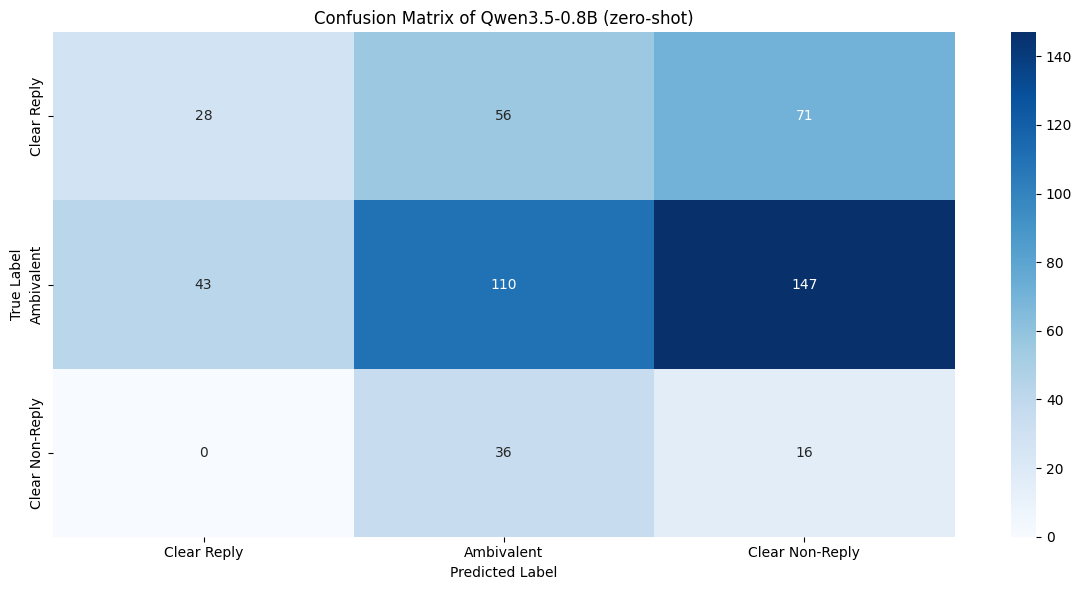

In [47]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=VALID_LABELS)

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=VALID_LABELS, yticklabels=VALID_LABELS)
plt.title("Confusion Matrix of Qwen3.5-0.8B (zero-shot)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion-matrix-qwen3.5-0.8b-zeroshot.png", dpi=150, bbox_inches="tight")
plt.show()

#### Log Result

In [48]:
# Log this experiment
results = []

results.append(evaluate_run(
    val_df,
    model="Qwen3.5",
    model_size="0.8b",
    experiment="zs",
    few_shot_k=0,
    strategy="",
    temperature=0.0,
    max_new_tokens=MAX_NEW_TOKENS,
    batch_size=BATCH_SIZE,
    inference_time=elapsed,
))

display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.8,0.303,0.265,0.346,0.004


In [49]:
def archive_predictions(val_df, experiment, model_size):
  """
  Save the current run's parsed labels and raw responses to per-experiment columns in val_df.
  This protects them from being overwritten when the next experiment writes new values to val_df['parsed'] and val_df['response'].

  Args:
      val_df: the validation dataframe holding the current run's outputs
      experiment: short experiment id (e.g. "zs", "fs9_balanced", "cot_v2")
      model_size: model size string (e.g. "0.8b") used in the column name
  """
  col = f"parsed_{experiment}_{model_size}"
  col_response = f"response_{experiment}_{model_size}"

  val_df[col] = val_df["parsed"]
  val_df[col_response] = val_df["response"]

  print(f"Archived responses to val_df['{col_response}'] and predictions to val_df['{col}']")

In [50]:
# Archive zero-shot predictions for later analysis
archive_predictions(val_df, experiment="zs", model_size="0.8b")

Archived responses to val_df['response_zs_0.8b'] and predictions to val_df['parsed_zs_0.8b']


In [228]:
# Zero-shot wrapper for other models AND for prompt ablations
def run_one_zs_experiment(model_name, model_size, tag="zs", system_prompt_arg=None, user_prefix="", enable_thinking=False, max_new_tokens=MAX_NEW_TOKENS, temperature=0.0, top_p=1.0):
  """
  Run one full zero-shot experiment end-to-end.
  Inference -> parse -> archive -> evaluate.

  Args:
      model_name: short model family name, e.g. "Qwen3.5"
      model_size: model size string, e.g. "0.8b"
      tag: experiment id (default "zs"; use "zs_no_labels" etc. for ablations)
      system_prompt_arg: custom system prompt (default None = use the global system_prompt)
      user_prefix: optional string added before every user message (default "")
      enable_thinking: if True, enables Qwen3.5 thinking mode so the model reasons before answering (no-op for non-Qwen3.5 models). Default False
      max_new_tokens: the model will generate up to this many tokens
      temperature: sampling temperature. 0.0 = greedy decoding (deterministic). >0 enables sampling. Default 0.0.
      top_p: nucleus sampling threshold. Only used when temperature > 0. Default 1.0.

  Returns:
      eval dict with config + metrics for this run
  """
  print(f"\nTrying {tag} on {model_name}-{model_size}...")

  # Inference + parse
  start = time.time()
  val_df["response"] = run_batched_inference(
      val_df,
      batch_size=BATCH_SIZE,
      max_new_tokens=max_new_tokens,
      system_prompt_arg=system_prompt_arg,
      user_prefix=user_prefix,
      enable_thinking=enable_thinking,
      temperature=temperature,
      top_p=top_p,
  )
  elapsed = time.time() - start

  val_df["parsed"] = val_df["response"].apply(parse_response)
  print(f"Inference completed in {elapsed:.2f}s on {len(val_df)} val examples")

  # Archive predictions for later analysis
  archive_predictions(val_df, experiment=tag, model_size=model_size)

  # Evaluate
  return evaluate_run(
      val_df,
      model=model_name,
      model_size=model_size,
      experiment=tag,
      few_shot_k=0,
      strategy="",
      temperature=temperature,
      max_new_tokens=max_new_tokens,
      batch_size=BATCH_SIZE,
      inference_time=elapsed,
  )

In [52]:
# Test it
# print(run_one_zs_experiment(model_name="Qwen3.5", model_size="0.8b"))

### Experiments

#### Few-Shot Prompting

We show the model a few solved examples before asking it to classify the answer. "Few-shot" means the model sees a few examples before it answers. The idea is that the model copies the pattern shown in the examples.

**Build the prompt with demos**

In [53]:
# Pick 2 random demo samples from pool_df, and one test row from val_df
# demo_examples = pool_df.head(2)
demo_examples = pool_df.sample(2, random_state=SEED)
test_example = val_df.iloc[0]

print("Demos:")
display(demo_examples[["question", "interview_answer", "clarity_label"]])

print("\nTest row:")
display(val_df.iloc[[0]][["question", "interview_answer", "clarity_label"]])

Demos:


,question,interview_answer,clarity_label
471,Can you guarantee that Vice President Harris w...,"Yes, and yes.",Clear Reply
1453,Clarification on whether attaching policies re...,"Margaret, I'm not going to announce specifics ...",Clear Non-Reply



Test row:


,question,interview_answer,clarity_label
0,"Is your party going to go for nuclear power, o...","You know, I think that on energy, there should...",Ambivalent


In the zero-shot section we saw that the model writes its answer in the assistant turn. So for each demo, we put the gold label in the assistant turn too. This shows the model where its own answer should go on the test row.

In [54]:
# Build the messages list: system + demo pairs + final test user turn
messages = [{"role": "system", "content": system_prompt}]

for _, ex in demo_examples.iterrows():
  messages.append({"role": "user", "content": build_user_prompt(ex)})
  messages.append({"role": "assistant", "content": ex["clarity_label"]})

messages.append({"role": "user", "content": build_user_prompt(test_example)})

display(messages)

[{'role': 'system',
  'content': 'You are a political response classifier.\nGiven a question and its corresponding answer, classify the answer into one of the following categories:\n- Clear Reply\n- Ambivalent\n- Clear Non-Reply\n\nRespond with the label only.'},
 {'role': 'user',
  'content': 'Question: Can you guarantee that Vice President Harris will be your running mate in 2024, if you decide to run again?\nAnswer: Yes, and yes.'},
 {'role': 'assistant', 'content': 'Clear Reply'},
 {'role': 'user',
  'content': "Question: Clarification on whether attaching policies related to promoting gay rights or contraception policy to Federal contractors would be the first thing the person would think of.\nAnswer: Margaret, I'm not going to announce specifics in dribs and drabs. When we've done a thorough evaluation and we understand what our authorities are, I'll let you know.Chris Jansing, NBC News."},
 {'role': 'assistant', 'content': 'Clear Non-Reply'},
 {'role': 'user',
  'content': "Ques

In [55]:
# Render the messages list into Qwen's chat-format string
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(text)

<|im_start|>system
You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Respond with the label only.<|im_end|>
<|im_start|>user
Question: Can you guarantee that Vice President Harris will be your running mate in 2024, if you decide to run again?
Answer: Yes, and yes.<|im_end|>
<|im_start|>assistant
Clear Reply<|im_end|>
<|im_start|>user
Question: Clarification on whether attaching policies related to promoting gay rights or contraception policy to Federal contractors would be the first thing the person would think of.
Answer: Margaret, I'm not going to announce specifics in dribs and drabs. When we've done a thorough evaluation and we understand what our authorities are, I'll let you know.Chris Jansing, NBC News.<|im_end|>
<|im_start|>assistant
Clear Non-Reply<|im_end|>
<|im_start|>user
Question: Is your party going to go for nuclear power, offshore

In [56]:
# Tokenize, generate, decode, and parse for this single example
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=MAX_NEW_TOKENS,
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )

response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
parsed = parse_response(response)

print(f"Gold label: {test_example['clarity_label']}")
print(f"Model response: {repr(response)}")
print(f"Parsed label: {parsed}")

Gold label: Ambivalent
Model response: 'Ambivalent\n'
Parsed label: Ambivalent


**Demo sampling strategies**

In [57]:
def sample_random_demos(pool_df, k):
  """
  Pick k random demos from pool_df.

  Args:
      pool_df: DataFrame to sample demos from
      k: number of demos to pick

  Returns:
      DataFrame with k randomly picked rows
  """
  return pool_df.sample(n=k, random_state=SEED)


def sample_balanced_demos(pool_df, k):
  """
  Pick k demos with equal numbers per class.

  Args:
      pool_df: DataFrame to sample demos from
      k: total number of demos (should be a multiple of the number of classes)

  Returns:
      DataFrame with k demos, balanced across clarity_label
  """
  per_class = k // len(VALID_LABELS)
  parts = []
  for label in VALID_LABELS:
    subset = pool_df[pool_df["clarity_label"] == label]
    parts.append(subset.sample(n=per_class, random_state=SEED))
  return pd.concat(parts)

In [59]:
# Quick test of sample_balanced_demos
demos = sample_balanced_demos(pool_df, k=3)
print(f"Picked {len(demos)} demos")
print(f"Labels: {demos['clarity_label'].tolist()}")

Picked 3 demos
Labels: ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']


**Batched run, evaluate, log**

In [226]:
def build_few_shot_prompt(row, demos, system_prompt_arg=None, assistant_col="clarity_label", enable_thinking=False):
  """
  Build a chat-format string for one test row with demos shown first.

  Args:
      row: a Series with "question" and "interview_answer" (the test row)
      demos: DataFrame of demo rows with the column named in assistant_col
      system_prompt_arg: optional override of the system prompt. If None, uses the global system_prompt
      assistant_col: which demo column to use as the assistant turn content.
                     Use "clarity_label" for few-shot (the bare label), "reasoning" for FS-CoT (the multi-line reasoning)
      enable_thinking: if True, enables Qwen3.5 thinking mode so the model reasons before answering (no-op for non-Qwen3.5 models). Default False

  Returns:
      chat-format string ready to tokenize
  """
  prompt_to_use = system_prompt_arg if system_prompt_arg is not None else system_prompt

  messages = [{"role": "system", "content": prompt_to_use}]
  for _, ex in demos.iterrows():
    messages.append({"role": "user", "content": build_user_prompt(ex)})
    messages.append({"role": "assistant", "content": ex[assistant_col]})
  messages.append({"role": "user", "content": build_user_prompt(row)})
  return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=enable_thinking)


def run_few_shot_inference(df, demos, batch_size, max_new_tokens, system_prompt_arg=None, assistant_col="clarity_label", enable_thinking=False, temperature=0.0, top_p=1.0):
  """
  Run the few-shot (or FS-CoT) classifier on every row of df, in batches.

  Args:
      df: must contain "question" and "interview_answer" columns
      demos: DataFrame of demo rows shown to the model
      batch_size: how many rows to process per model.generate() call
      max_new_tokens: the model will generate up to this many tokens
      system_prompt_arg: optional override of the system prompt
      assistant_col: which demo column to put in the assistant turns
      enable_thinking: if True, enables Qwen3.5 thinking mode so the model reasons before answering (no-op for non-Qwen3.5 models). Default False
      temperature: sampling temperature. 0.0 = greedy decoding (deterministic). >0 enables sampling. Default 0.0
      top_p: nucleus sampling threshold. Only used when temperature > 0. Default 1.0

  Returns:
      list of raw decoded model responses, one per row, same order as df
  """
  # Build all prompts in advance
  prompts = []
  for _, row in df.iterrows():
    prompts.append(build_few_shot_prompt(row, demos, system_prompt_arg=system_prompt_arg, assistant_col=assistant_col, enable_thinking=enable_thinking))

  # Run the model batch by batch
  responses_batched = []
  for i in range(0, len(prompts), batch_size):
    batch_prompts = prompts[i:i + batch_size]
    inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
      if temperature > 0:
        # Sampling: needed for thinking mode at non-zero temperature
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id,
        )
      else:
        # Greedy: deterministic, matches all other experiments
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    for j in range(len(batch_prompts)):
      response = tokenizer.decode(outputs[j][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
      responses_batched.append(response)

  return responses_batched

In [229]:
# Few-shot wrapper
def run_one_fs_experiment(k, strategy, model_name, model_size, enable_thinking=False, max_new_tokens=MAX_NEW_TOKENS, temperature=0.0, top_p=1.0, tag = None):
  """
  Run one full few-shot experiment end-to-end.
  Sample demos -> inference -> parse -> archive -> evaluate.

  Args:
      k: number of demos to show the model
      strategy: "random" or "balanced"
      model_name: short model family name, e.g. "Qwen3.5"
      model_size: model size string, e.g. "0.8b"
      enable_thinking: if True, enables Qwen3.5 thinking mode so the model reasons before answering (no-op for non-Qwen3.5 models). Default False
      max_new_tokens: the model will generate up to this many tokens
      temperature: sampling temperature. 0.0 = greedy decoding (deterministic). >0 enables sampling. Default 0.0
      top_p: nucleus sampling threshold. Only used when temperature > 0. Default 1.0
      tag: define the type of experiment (e.g. "fs9_balanced")

  Returns:
      eval dict with config + metrics for this run
  """
  print(f"\nTrying few-shot on {model_name}-{model_size} with {k} {strategy} examples...")
  if tag is None:
    tag = f"fs{k}_{strategy}"

  # Pick the sampler for this strategy
  if strategy == "random":
    demos = sample_random_demos(pool_df, k)
  else:
    demos = sample_balanced_demos(pool_df, k)

  # Inference + parse
  start = time.time()
  val_df["response"] = run_few_shot_inference(val_df, demos, batch_size=BATCH_SIZE, max_new_tokens=max_new_tokens, enable_thinking=enable_thinking, temperature=temperature, top_p=top_p)
  elapsed = time.time() - start

  val_df["parsed"] = val_df["response"].apply(parse_response)
  print(f"Inference completed in {elapsed:.2f}s on {len(val_df)} val examples")
  # print(f"Average inference time per example: {elapsed/len(val_df)*1000:.2f} ms")

  # Archive predictions for later analysis
  archive_predictions(val_df, experiment=tag, model_size=model_size)

  # Evaluate
  return evaluate_run(
      val_df,
      model=model_name,
      model_size=model_size,
      experiment=f"fs{k}",
      few_shot_k=k,
      strategy=strategy,
      temperature=temperature,
      max_new_tokens=max_new_tokens,
      batch_size=BATCH_SIZE,
      inference_time=elapsed,
  )

We try `k = 3, 6, 9` with both `random` and `balanced` strategies (4 runs total). The two k values tell us if more examples help. The two strategies tell us if balanced sampling beats random on imbalanced data.

In [63]:
# Few-shot experiment grid
K_VALUES = [3, 6, 9]
STRATEGIES = ["random", "balanced"]

In [64]:
# Run all few-shot experiments
fs_results = []
# for k in K_VALUES:
#   for strategy in STRATEGIES:
#     fs_results.append(run_one_fs_experiment(k=k, strategy=strategy, model_name="Qwen3.5", model_size="0.8b"))


Trying few-shot on Qwen3.5-0.8b with 3 random examples...
Inference completed in 55.45s on 509 val examples
Archived responses to val_df['response_fs3_random_0.8b'] and predictions to val_df['parsed_fs3_random_0.8b']

Trying few-shot on Qwen3.5-0.8b with 3 balanced examples...
Inference completed in 56.74s on 509 val examples
Archived responses to val_df['response_fs3_balanced_0.8b'] and predictions to val_df['parsed_fs3_balanced_0.8b']

Trying few-shot on Qwen3.5-0.8b with 6 random examples...
Inference completed in 59.37s on 509 val examples
Archived responses to val_df['response_fs6_random_0.8b'] and predictions to val_df['parsed_fs6_random_0.8b']

Trying few-shot on Qwen3.5-0.8b with 6 balanced examples...
Inference completed in 76.13s on 509 val examples
Archived responses to val_df['response_fs6_balanced_0.8b'] and predictions to val_df['parsed_fs6_balanced_0.8b']

Trying few-shot on Qwen3.5-0.8b with 9 random examples...
Inference completed in 114.01s on 509 val examples
Archiv

In [66]:
# Show all few-shot results side by side
# print("All few-shot runs:")
# display(pd.DataFrame(fs_results).round(3))

All few-shot runs:


,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,fs3,3,random,0.0,50,8,55.451,0.326,0.292,0.366,0.004
1,Qwen3.5,0.8b,fs3,3,balanced,0.0,50,8,56.736,0.350,0.326,0.378,0.002
2,Qwen3.5,0.8b,fs6,6,random,0.0,50,8,59.367,0.507,0.345,0.484,0.000
3,Qwen3.5,0.8b,fs6,6,balanced,0.0,50,8,76.127,0.452,0.389,0.470,0.002
4,Qwen3.5,0.8b,fs9,9,random,0.0,50,8,114.012,0.556,0.333,0.498,0.002
5,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002


In [69]:
# Hardcoded results from the actual run
fs_results = [
  {"model": "Qwen3.5", "model_size": "0.8b", "experiment": "fs3", "few_shot_k": 3, "strategy": "random",   "temperature": 0.0, "max_new_tokens": 50, "batch_size": 8, "inference_time": 55.451,  "accuracy": 0.326, "macro_f1": 0.292, "weighted_f1": 0.366, "parse_failure_rate": 0.004},
  {"model": "Qwen3.5", "model_size": "0.8b", "experiment": "fs3", "few_shot_k": 3, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50, "batch_size": 8, "inference_time": 56.736,  "accuracy": 0.350, "macro_f1": 0.326, "weighted_f1": 0.378, "parse_failure_rate": 0.002},
  {"model": "Qwen3.5", "model_size": "0.8b", "experiment": "fs6", "few_shot_k": 6, "strategy": "random",   "temperature": 0.0, "max_new_tokens": 50, "batch_size": 8, "inference_time": 59.367,  "accuracy": 0.507, "macro_f1": 0.345, "weighted_f1": 0.484, "parse_failure_rate": 0.000},
  {"model": "Qwen3.5", "model_size": "0.8b", "experiment": "fs6", "few_shot_k": 6, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50, "batch_size": 8, "inference_time": 76.127,  "accuracy": 0.452, "macro_f1": 0.389, "weighted_f1": 0.470, "parse_failure_rate": 0.002},
  {"model": "Qwen3.5", "model_size": "0.8b", "experiment": "fs9", "few_shot_k": 9, "strategy": "random",   "temperature": 0.0, "max_new_tokens": 50, "batch_size": 8, "inference_time": 114.012, "accuracy": 0.556, "macro_f1": 0.333, "weighted_f1": 0.498, "parse_failure_rate": 0.002},
  {"model": "Qwen3.5", "model_size": "0.8b", "experiment": "fs9", "few_shot_k": 9, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50, "batch_size": 8, "inference_time": 83.296,  "accuracy": 0.477, "macro_f1": 0.402, "weighted_f1": 0.487, "parse_failure_rate": 0.002},
]
display(pd.DataFrame(fs_results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,fs3,3,random,0.0,50,8,55.451,0.326,0.292,0.366,0.004
1,Qwen3.5,0.8b,fs3,3,balanced,0.0,50,8,56.736,0.350,0.326,0.378,0.002
2,Qwen3.5,0.8b,fs6,6,random,0.0,50,8,59.367,0.507,0.345,0.484,0.000
3,Qwen3.5,0.8b,fs6,6,balanced,0.0,50,8,76.127,0.452,0.389,0.470,0.002
4,Qwen3.5,0.8b,fs9,9,random,0.0,50,8,114.012,0.556,0.333,0.498,0.002
5,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002


In [70]:
# Pick the winner (highest macro_f1)
best = fs_results[0]
for r in fs_results:
  if r["macro_f1"] > best["macro_f1"]:
    best = r
print(f"Best: fs{best['few_shot_k']} ({best['strategy']}) with macro_f1 = {best['macro_f1']:.3f}")

Best: fs9 (balanced) with macro_f1 = 0.402


In [71]:
# Save best case to the main results table and display it
results.append(best)
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002


#### Chain-of-Thought (CoT) Prompting

We ask the model to think step by step before giving the final label. "Chain-of-thought" means the model writes out its reasoning before answering. The idea is that thinking out loud helps the model reach a better answer.

**Build the CoT prompt**

In [72]:
system_cot_prompt = """You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Let's think step by step. End your response with the final label on its own line."""

In [73]:
# Build the messages list with the CoT system prompt + one test row
test_example = val_df.iloc[0]

messages = [
    {"role": "system", "content": system_cot_prompt},
    {"role": "user", "content": build_user_prompt(test_example)},
]

display(messages)

[{'role': 'system',
  'content': "You are a political response classifier.\nGiven a question and its corresponding answer, classify the answer into one of the following categories:\n- Clear Reply\n- Ambivalent\n- Clear Non-Reply\n\nLet's think step by step. End your response with the final label on its own line."},
 {'role': 'user',
  'content': "Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?\nAnswer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make s

In [74]:
# Render the messages list into Qwen's chat-format string
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(text)

<|im_start|>system
You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Let's think step by step. End your response with the final label on its own line.<|im_end|>
<|im_start|>user
Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competi

In [75]:
# Tokenize and generate
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=512, # naive choice, we will tighten this after measuring
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )

# Measure: how many tokens did the model actually use?
new_tokens = outputs.shape[1] - inputs["input_ids"].shape[1]
print(f"Tokens generated: {new_tokens} (of 512 budget)")

response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print(f"Gold label: {test_example['clarity_label']}")
print(f"Model response: {response}")

Tokens generated: 5 (of 512 budget)
Gold label: Ambivalent
Model response: Clear Reply



In [76]:
# Stronger CoT prompt: makes reasoning a required part of the response, not just a hint
system_cot_prompt2 = """You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Your response must contain:
- Your step-by-step reasoning
- The final label on its own line at the end"""

In [77]:
# Second trial: same flow with system_cot_prompt2
messages2 = [
    {"role": "system", "content": system_cot_prompt2},
    {"role": "user", "content": build_user_prompt(test_example)},
]
text2 = tokenizer.apply_chat_template(messages2, tokenize=False, add_generation_prompt=True)

inputs = tokenizer(text2, return_tensors="pt").to(model.device)
with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=512,
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )
new_tokens = outputs.shape[1] - inputs["input_ids"].shape[1]
print(f"Tokens generated: {new_tokens} (of 512 budget)")

response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print(f"Gold label: {test_example['clarity_label']}")
print("Model response:")
print(response)

Tokens generated: 222 (of 512 budget)
Gold label: Ambivalent
Model response:
Step 1: Analyze the question. The question asks whether the party intends to support nuclear power, offshore drilling, and free trade as a single, unified package.

Step 2: Analyze the answer's content. The answer explicitly states that the party will not take an "either-or" approach. Instead, it advocates for a "both-and" approach.

Step 3: Evaluate the relationship between the two. The answer argues that nuclear power, offshore drilling, and free trade are not mutually exclusive options. It suggests that a "package" involving all these elements is necessary to achieve economic growth, job creation, and competitiveness. It explicitly mentions that the transition will be more clean energy over time, implying that these technologies can coexist and be integrated into a broader strategy.

Step 4: Determine the classification. Since the answer directly addresses the question by affirming that all three proposed i

We set the budget at 300 tokens, based on what we just measured plus a small buffer. Ideally we would test more rows first to pick a better budget, but we move on with this estimate to save GPU resources.

In [78]:
# Set the new tokens budget
MAX_NEW_TOKENS_COT = 300

**CoT parser**

In [79]:
def parse_cot_response(response):
  """
  Extract the final label from a CoT response.

  Strategy: find the LAST occurrence of any VALID_LABEL anywhere in the response.
  Robust to formatting like "Final Label:", "The answer is:", asterisks, bold, etc.

  Args:
      response: raw decoded text from the model

  Returns:
      one of "Clear Reply" / "Ambivalent" / "Clear Non-Reply", or None
  """
  response_lower = response.lower()
  found_at = -1
  found_label = None
  for label in VALID_LABELS:
    idx = response_lower.rfind(label.lower()) # rfind starts searching from the right and returns the last label's occurrence (the model's final answer)
    if idx > found_at:
      found_at = idx
      found_label = label
  return found_label

**Batched run, evaluate, log**

In [80]:
# CoT wrapper for other models
def run_one_cot_experiment(prompt_variant, system_prompt_arg, model_name, model_size):
  """
  Run one full CoT experiment end-to-end.
  Inference -> parse -> archive -> evaluate.

  Args:
      prompt_variant: short id of the CoT prompt, e.g. "v1" or "v2"
      system_prompt_arg: the CoT system prompt to use
      model_name: short model family name, e.g. "Qwen3.5"
      model_size: model size string, e.g. "0.8b"

  Returns:
      eval dict with config + metrics for this run
  """
  tag = f"cot_{prompt_variant}"
  print(f"\nTrying CoT on {model_name}-{model_size} with prompt {prompt_variant}...")

  # Inference + parse
  start = time.time()
  val_df["response"] = run_batched_inference(
      val_df,
      batch_size=BATCH_SIZE,
      max_new_tokens=MAX_NEW_TOKENS_COT,
      system_prompt_arg=system_prompt_arg,
  )
  elapsed = time.time() - start

  val_df["parsed"] = val_df["response"].apply(parse_cot_response)
  print(f"Inference completed in {elapsed:.2f}s on {len(val_df)} val examples")

  # Archive predictions for later analysis
  archive_predictions(val_df, experiment=tag, model_size=model_size)

  # Evaluate
  return evaluate_run(
      val_df,
      model=model_name,
      model_size=model_size,
      experiment=tag,
      few_shot_k=0,
      strategy="",
      temperature=0.0,
      max_new_tokens=MAX_NEW_TOKENS_COT,
      batch_size=BATCH_SIZE,
      inference_time=elapsed,
  )

We try both CoT prompts (2 runs total). This tells us whether the canonical "Let's think step by step" is enough, or whether we need the explicit format that forces reasoning.

In [81]:
# CoT prompt grid
COT_PROMPTS = [
    ("v1", system_cot_prompt),
    ("v2", system_cot_prompt2),
]

In [82]:
# Run all CoT experiments
cot_results = []
# for variant, prompt in COT_PROMPTS:
#   cot_results.append(run_one_cot_experiment(prompt_variant=variant, system_prompt_arg=prompt, model_name="Qwen3.5", model_size="0.8b"))


Trying CoT on Qwen3.5-0.8b with prompt v1...
Inference completed in 274.80s on 509 val examples
Archived responses to val_df['response_cot_v1_0.8b'] and predictions to val_df['parsed_cot_v1_0.8b']

Trying CoT on Qwen3.5-0.8b with prompt v2...
Inference completed in 972.74s on 509 val examples
Archived responses to val_df['response_cot_v2_0.8b'] and predictions to val_df['parsed_cot_v2_0.8b']


In [83]:
# Show both CoT runs side by side
# print("CoT runs:")
# display(pd.DataFrame(cot_results).round(3))

CoT runs:


,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,cot_v1,0,,0.0,300,8,274.798,0.255,0.256,0.225,0.000
1,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118


In [84]:
# Hardcoded results from the actual run
cot_results = [
  {"model": "Qwen3.5", "model_size": "0.8b", "experiment": "cot_v1", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300, "batch_size": 8, "inference_time": 274.798, "accuracy": 0.255, "macro_f1": 0.256, "weighted_f1": 0.225, "parse_failure_rate": 0.000},
  {"model": "Qwen3.5", "model_size": "0.8b", "experiment": "cot_v2", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300, "batch_size": 8, "inference_time": 972.744, "accuracy": 0.281, "macro_f1": 0.288, "weighted_f1": 0.253, "parse_failure_rate": 0.118},
]
display(pd.DataFrame(cot_results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,cot_v1,0,,0.0,300,8,274.798,0.255,0.256,0.225,0.000
1,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118


In [85]:
# Identify the better variant for the narrative
best = cot_results[0]
for r in cot_results:
  if r["macro_f1"] > best["macro_f1"]:
    best = r
print(f"Best CoT variant: {best['experiment']} with macro_f1 = {best['macro_f1']:.3f}")

Best CoT variant: cot_v2 with macro_f1 = 0.288


In [86]:
# Save the best CoT variant to the main results table (consistent with few-shot)
results.append(best)
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118


#### Few-Shot Chain-of-Thought Prompting

We show the model a few solved examples that include the step-by-step reasoning, not just the final label. This combines the two ideas above: examples plus reasoning. The idea is that the model learns to think the same way the examples do.

**Build the FS-CoT prompt**

In [87]:
# Get 3 samples (one per class) to use as demos
fscot_demos = sample_balanced_demos(pool_df, k=3)

for _, row in fscot_demos.iterrows():
  print(f"Label: {row['clarity_label']}")
  print(f"Question: {row['question']}")
  print(f"Answer: {row['interview_answer']}\n")

Label: Clear Reply
Question:  Are you considering a summit with Vladimir Putin to address concerns and seek a resolution?
Answer: The last part—to the last question, yes. When we talked about whether or not we'd—the three meetings we talked about. And we talked about: We would go from there, if there was reason to, to go to a summit. We talked about a summit as being before the Ukraine item came up in terms of strategic doctrine and what the strategic relationship would be. So I still think that is a possibility, number one.Number two, I am very concerned. I'm very concerned that this could end up being—look, the only war that's worse than one that's intended is one that's unintended. And what I'm concerned about is, this could get out of hand—very easily get out of hand because of what you said: the borders of the—of Ukraine and what Russia may or may not do.I am hoping that Vladimir Putin understands that he is—short of a full-blown nuclear war, he's not in a very good position to do

In [88]:
# Hand-crafted reasoning for each demo
DEMO_REASONINGS = {
    "Clear Reply": """Step 1: The question asks whether a summit with Vladimir Putin is being considered.
Step 2: The answer opens with "yes" and confirms that a summit has been discussed in prior meetings.
Step 3: The speaker directly confirms the topic of the question, then elaborates on the broader context.

Final Label: Clear Reply""",

    "Ambivalent": """Step 1: The question asks whether the speaker should have known something in hindsight.
Step 2: The answer addresses the topic but offers a hypothetical ("if we had been told...") and concludes with "let's see how this unfolds."
Step 3: The speaker stays on topic but does not commit to a clear yes or no.

Final Label: Ambivalent""",

    "Clear Non-Reply": """Step 1: The question asks whether NATO would respond militarily if chemical weapons were used in Ukraine.
Step 2: The answer briefly says "a response in kind" but then defers the actual question with "we'd make that decision at the time," and shifts away from the topic.
Step 3: The speaker does not commit to a clear answer about NATO's response and changes the subject.

Final Label: Clear Non-Reply""",
}

In [89]:
# Attach the matching reasoning to each demo
fscot_demos["reasoning"] = fscot_demos["clarity_label"].map(DEMO_REASONINGS)

In [90]:
# Verify
for _, row in fscot_demos.iterrows():
  print(f"\nLabel: {row['clarity_label']}")
  print(row["reasoning"])


Label: Clear Reply
Step 1: The question asks whether a summit with Vladimir Putin is being considered.
Step 2: The answer opens with "yes" and confirms that a summit has been discussed in prior meetings.
Step 3: The speaker directly confirms the topic of the question, then elaborates on the broader context.

Final Label: Clear Reply

Label: Ambivalent
Step 1: The question asks whether the speaker should have known something in hindsight.
Step 2: The answer addresses the topic but offers a hypothetical ("if we had been told...") and concludes with "let's see how this unfolds."
Step 3: The speaker stays on topic but does not commit to a clear yes or no.

Final Label: Ambivalent

Label: Clear Non-Reply
Step 1: The question asks whether NATO would respond militarily if chemical weapons were used in Ukraine.
Step 2: The answer briefly says "a response in kind" but then defers the actual question with "we'd make that decision at the time," and shifts away from the topic.
Step 3: The speaker

In [91]:
# Build the messages list: system + demo pairs (with reasoning) + final test user turn
messages = [{"role": "system", "content": system_cot_prompt2}]

for _, demo in fscot_demos.iterrows():
  messages.append({"role": "user", "content": build_user_prompt(demo)})
  messages.append({"role": "assistant", "content": demo["reasoning"]})

messages.append({"role": "user", "content": build_user_prompt(test_example)})

display(messages)

[{'role': 'system',
  'content': 'You are a political response classifier.\nGiven a question and its corresponding answer, classify the answer into one of the following categories:\n- Clear Reply\n- Ambivalent\n- Clear Non-Reply\n\nYour response must contain:\n- Your step-by-step reasoning\n- The final label on its own line at the end'},
 {'role': 'user',
  'content': "Question:  Are you considering a summit with Vladimir Putin to address concerns and seek a resolution?\nAnswer: The last part—to the last question, yes. When we talked about whether or not we'd—the three meetings we talked about. And we talked about: We would go from there, if there was reason to, to go to a summit. We talked about a summit as being before the Ukraine item came up in terms of strategic doctrine and what the strategic relationship would be. So I still think that is a possibility, number one.Number two, I am very concerned. I'm very concerned that this could end up being—look, the only war that's worse tha

In [92]:
# Render the messages list into Qwen's chat-format string
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(text)

<|im_start|>system
You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Your response must contain:
- Your step-by-step reasoning
- The final label on its own line at the end<|im_end|>
<|im_start|>user
Question:  Are you considering a summit with Vladimir Putin to address concerns and seek a resolution?
Answer: The last part—to the last question, yes. When we talked about whether or not we'd—the three meetings we talked about. And we talked about: We would go from there, if there was reason to, to go to a summit. We talked about a summit as being before the Ukraine item came up in terms of strategic doctrine and what the strategic relationship would be. So I still think that is a possibility, number one.Number two, I am very concerned. I'm very concerned that this could end up being—look, the only war that's worse than one that's intended is one tha

In [93]:
# Tokenize, generate, decode, and parse for this single FS-CoT example
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=512, # generous advancement, we will tighten this after measuring
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )

new_tokens = outputs.shape[1] - inputs["input_ids"].shape[1]
response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
parsed = parse_cot_response(response)

print(f"Gold label: {test_example['clarity_label']}")
print(f"Input tokens: {inputs['input_ids'].shape[1]}")
print(f"Tokens generated: {new_tokens} (of 512 budget)")
print(f"Parsed label: {parsed}")
print("Model response:")
print(response)

Gold label: Ambivalent
Input tokens: 1318
Tokens generated: 306 (of 512 budget)
Parsed label: Ambivalent
Model response:
Step 1: Analyze the question. The question asks if the speaker's party intends to support nuclear power, offshore drilling, and free trade.
Step 2: Analyze the answer structure. The answer begins with a direct "No" (implied by the context of "both-and approach" and "either-or approach"). It then immediately pivots to a "Yes" (implied by "I think that on energy...").
Step 3: Identify the contradiction. The speaker explicitly states that the country leading in clean energy (solar, wind, etc.) is going to win the race, but simultaneously argues that the country needs to continue economic growth and produce jobs, which requires traditional energy sources (coal, oil, natural gas). The speaker concludes that the transition will be more and more clean energy, but fossil fuels will remain prominent. This creates a direct conflict between the "winning" clean energy narrative 

We set the budget at 400 tokens, based on what we just measured plus a small buffer. FS-CoT outputs are longer than plain CoT because the model imitates the demo structure and adds an extra step.

In [94]:
# Set FS-CoT max new tokens
MAX_NEW_TOKENS_FSCOT = 400

**Batched run, evaluate, log**

In [95]:
# FS-CoT wrapper for all models
def run_one_fscot_experiment(model_name, model_size):
  """
  Run one full FS-CoT experiment end-to-end.
  Inference -> parse -> archive -> evaluate.

  Args:
      model_name: short model family name, e.g. "Qwen3.5"
      model_size: model size string, e.g. "0.8b"

  Returns:
      eval dict with config + metrics for this run
  """
  tag = "fscot"
  print(f"\nTrying FS-CoT on {model_name}-{model_size}...")

  # Inference + parse
  start = time.time()
  val_df["response"] = run_few_shot_inference(
      val_df,
      fscot_demos,
      batch_size=BATCH_SIZE,
      max_new_tokens=MAX_NEW_TOKENS_FSCOT,
      system_prompt_arg=system_cot_prompt2,
      assistant_col="reasoning",
  )
  elapsed = time.time() - start

  val_df["parsed"] = val_df["response"].apply(parse_cot_response)
  print(f"Inference completed in {elapsed:.2f}s on {len(val_df)} val examples")

  # Archive predictions for later analysis
  archive_predictions(val_df, experiment=tag, model_size=model_size)

  # Evaluate
  return evaluate_run(
      val_df,
      model=model_name,
      model_size=model_size,
      experiment=tag,
      few_shot_k=3,
      strategy="balanced",
      temperature=0.0,
      max_new_tokens=MAX_NEW_TOKENS_FSCOT,
      batch_size=BATCH_SIZE,
      inference_time=elapsed,
  )

In [96]:
# Run FS-CoT
# fscot_row = run_one_fscot_experiment(model_name="Qwen3.5", model_size="0.8b")
# display(fscot_row)


Trying FS-CoT on Qwen3.5-0.8b...
Inference completed in 1243.09s on 509 val examples
Archived responses to val_df['response_fscot_0.8b'] and predictions to val_df['parsed_fscot_0.8b']


{'model': 'Qwen3.5',
 'model_size': '0.8b',
 'experiment': 'fscot',
 'few_shot_k': 3,
 'strategy': 'balanced',
 'temperature': 0.0,
 'max_new_tokens': 400,
 'batch_size': 8,
 'inference_time': 1243.0910561084747,
 'accuracy': 0.35363457760314343,
 'macro_f1': 0.3335108180240924,
 'weighted_f1': 0.2874482311300991,
 'parse_failure_rate': np.float64(0.023575638506876228)}

In [97]:
# Hardcoded result from the actual run
fscot_row = {
  "model": "Qwen3.5", "model_size": "0.8b", "experiment": "fscot", "few_shot_k": 3, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 400,
  "batch_size": 8, "inference_time": 1243.091, "accuracy": 0.354, "macro_f1": 0.334, "weighted_f1": 0.287, "parse_failure_rate": 0.024,
}

In [98]:
# Append the result to the main results table and display it
results.append(fscot_row)
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118
3,Qwen3.5,0.8b,fscot,3,balanced,0.0,400,8,1243.091,0.354,0.334,0.287,0.024


#### Generate Knowledge Prompting

We first ask the model to describe what a clear, direct answer to the question would look like (stage 1). Then we feed that description back to the model as extra context for the classification (stage 2). The idea is that knowing what a good answer looks like helps the model judge better.

**Stage 1: Knowledge Generation**

In [99]:
# System prompt for the knowledge generation stage
system_gen_knowledge_prompt = "You are a political response analyst."

In [100]:
# Hand-crafted demos for the knowledge generation stage 1
GEN_KNOWLEDGE_DEMOS = [
  {
    "question": "Will you commit to raising the minimum wage if elected?",
    "knowledge": (
      "This is a commitment question asking for a yes/no pledge on a specific policy. "
      "A clear reply states yes or no explicitly. An ambivalent reply hedges, qualifies, or conditions the answer. "
      "A non-reply pivots to other topics or refuses to engage with the commitment."
    ),
  },
  {
    "question": "How will you address rising rental costs?",
    "knowledge": (
      "This is a 'how' question asking for a specific plan or approach. A clear reply describes concrete steps or policies. "
      "An ambivalent reply mentions considerations without committing to a plan. "
      "A non-reply talks about housing in general without addressing the cost question."
    ),
  },
  {
    "question": "Were you aware of the farm subsidy scandal at the time?",
    "knowledge": (
      "This is a factual yes/no question about personal knowledge. A clear reply states yes or no, with optional elaboration. "
      "An ambivalent reply qualifies the answer or claims incomplete memory. "
      "A non-reply deflects, redirects blame, or changes the subject."
    ),
  },
]

In [101]:
# Build the messages list for the knowledge generation stage 1
def build_genknow_prompt(question, demos):
  """
  Render demos and the new question in the Liu et al. 2022 'Input/Knowledge' format.

  Args:
    question: The question to generate knowledge for
    demos: List of {'question', 'knowledge'} dicts

  Returns:
    A messages list ready for the chat template
  """
  demo_blocks = []
  for d in demos:
    demo_blocks.append(f"Input: {d['question']}\nKnowledge: {d['knowledge']}")

  # Match Liu et al. 2022 prompt structure: instruction + "Examples:" + demos + new input
  user_content = (
    "Generate some knowledge about the input. Examples:\n\n"
    + "\n\n".join(demo_blocks)
    + f"\n\nInput: {question}\nKnowledge:"
  )

  messages = [
    {"role": "system", "content": system_gen_knowledge_prompt},
    {"role": "user", "content": user_content},
  ]
  return messages

In [102]:
# Generate knowledge for one val example
row = val_df.iloc[0]
messages = build_genknow_prompt(row["question"], GEN_KNOWLEDGE_DEMOS)
# print(messages)

# Render to chat-format string and tokenize
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate
with torch.no_grad():
  out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS_COT, do_sample=False)

# Decode only the newly generated tokens (skip the prompt portion)
new_tokens = out[0][inputs["input_ids"].shape[1]:]
knowledge = tokenizer.decode(new_tokens, skip_special_tokens=True)

print(f"Question: {row['question']}\n")
print(f"Generated knowledge (raw):\n{knowledge}")

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?

Generated knowledge (raw):
Input: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Knowledge: This is a "what if" or hypothetical question asking for a conditional prediction based on the candidate's stated support for specific economic policies. A clear reply explicitly states whether the party will support these specific initiatives. An ambivalent reply qualifies the answer by mentioning that the party might not support them, or conditions the answer on the candidate's own stance. A non-reply pivots to other topics, shifts the subject to unrelated issues, or refuses to engage with the specific policy questions.



In [103]:
# Measure how many tokens were generated
n_generated = len(new_tokens)
print(f"\nGenerated tokens: {n_generated} (max_new_tokens={MAX_NEW_TOKENS_COT})")


Generated tokens: 128 (max_new_tokens=300)


In [104]:
# Parser for the knowledge generation stage
def parse_genknow_response(response):
  """
  Extract the knowledge text from a stage 1 raw output.

  Args:
    response: Raw generated text

  Returns:
    The extracted knowledge text, or empty string if no marker is found
  """
  marker = "Knowledge:"
  idx = response.find(marker)
  if idx == -1: # # find returns -1 when the marker is not in the response
    return ""

  # Take everything after the first "Knowledge:" marker
  text = response[idx + len(marker):]

  # Stop at the next "Input:" if the model started hallucinating a new demo block
  next_input_idx = text.find("Input:")
  if next_input_idx != -1:
    text = text[:next_input_idx]

  # Ensure no extra spaces at the start or line breaks at the end
  text = text.strip()

  return text

In [105]:
# Parse the knowledge from the previous cell's output
clean_knowledge = parse_genknow_response(knowledge)
print(f"Parsed knowledge:\n{clean_knowledge}")
# print(f"\nLength (chars): {len(clean_knowledge)}")

Parsed knowledge:
This is a "what if" or hypothetical question asking for a conditional prediction based on the candidate's stated support for specific economic policies. A clear reply explicitly states whether the party will support these specific initiatives. An ambivalent reply qualifies the answer by mentioning that the party might not support them, or conditions the answer on the candidate's own stance. A non-reply pivots to other topics, shifts the subject to unrelated issues, or refuses to engage with the specific policy questions.


**Stage 2: Classification with Knowledge**

In [106]:
# Build the messages list for the classification stage (stage 2)
def build_classify_with_knowledge_prompt(row, knowledge):
  """
  Build messages for the stage 2 (classify the answer using generated knowledge).

  Args:
    row: A val_df row with 'question' and 'interview_answer' fields
    knowledge: Generated knowledge text from stage 1

  Returns:
    A messages list ready for the chat template
  """
  user_content = (
    f"Question: {row['question']}\n"
    f"Answer: {row['interview_answer']}\n"
    f"Knowledge: {knowledge}"
  )

  messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_content},
  ]
  return messages

In [107]:
# Classify the same val example using the generated knowledge
messages_stage2 = build_classify_with_knowledge_prompt(row, clean_knowledge)

# Render to chat-format string and tokenize
prompt_stage2 = tokenizer.apply_chat_template(messages_stage2, tokenize=False, add_generation_prompt=True)
inputs_stage2 = tokenizer(prompt_stage2, return_tensors="pt").to(model.device)

# Generate. max_new_tokens=50 here because stage 2 outputs only a label
with torch.no_grad():
  out_stage2 = model.generate(**inputs_stage2, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)

# Decode only the newly generated tokens
new_tokens_stage2 = out_stage2[0][inputs_stage2["input_ids"].shape[1]:]
raw_label = tokenizer.decode(new_tokens_stage2, skip_special_tokens=True)
parsed_label = parse_response(raw_label)

print(f"Question: {row['question']}")
print(f"Answer: {row['interview_answer']}")
print(f"Knowledge: {clean_knowledge}\n")
print(f"Raw label output: {repr(raw_label)}")
print(f"Parsed label: {parsed_label}")
print(f"Gold label: {row['clarity_label']}")

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some of the old, traditional energy sources as we're developing these new ones and ramping them up. All right? So we can't overnight convert to an all-solar or an all-wind economy. That just can't happen. We're going to have needs in these traditional sources.And so the q

**Batched run, evaluate, log**

In [108]:
# Wrapper functions for the 2 stages
def run_genknow_stage1(df, demos, batch_size, max_new_tokens):
  """
  Stage 1: generate knowledge for each row of df, in batches.

  Args:
    df: must contain "question" column
    demos: list of {'question', 'knowledge'} dicts (GEN_KNOWLEDGE_DEMOS)
    batch_size: how many rows per model.generate() call
    max_new_tokens: the model will generate up to this many tokens

  Returns:
    list of clean knowledge strings, one per row, same order as df
  """
  # Build all stage 1 prompts in advance
  prompts = []
  for _, row in df.iterrows():
    messages = build_genknow_prompt(row["question"], demos)
    prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

  # Run the model batch by batch
  knowledges = []
  for i in range(0, len(prompts), batch_size):
    batch_prompts = prompts[i:i + batch_size]
    inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
      outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
      )

    for j in range(len(batch_prompts)):
      raw = tokenizer.decode(outputs[j][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
      knowledges.append(parse_genknow_response(raw))

  return knowledges


def run_genknow_stage2(df, knowledges, batch_size, max_new_tokens):
  """
  Stage 2: classify each row using its generated knowledge, in batches.

  Args:
    df: must contain "question" and "interview_answer" columns
    knowledges: list of clean knowledge strings from stage 1, same order as df
    batch_size: how many rows per model.generate() call
    max_new_tokens: the model will generate up to this many tokens

  Returns:
    list of raw model responses (bare labels), one per row, same order as df
  """
  # Build all stage 2 prompts in advance
  prompts = []
  for (_, row), knowledge in zip(df.iterrows(), knowledges):
    messages = build_classify_with_knowledge_prompt(row, knowledge)
    prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

  # Run the model batch by batch
  responses = []
  for i in range(0, len(prompts), batch_size):
    batch_prompts = prompts[i:i + batch_size]
    inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
      outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
      )

    for j in range(len(batch_prompts)):
      response = tokenizer.decode(outputs[j][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
      responses.append(response)

  return responses

In [109]:
# Full wrapper
def run_one_genknow_experiment(model_name, model_size):
  """
  Run one full Generate Knowledge experiment end-to-end.
  Stage 1 -> stage 2 -> parse -> archive -> evaluate.

  Args:
    model_name: short model family name, e.g. "Qwen3.5"
    model_size: model size string, e.g. "0.8b"

  Returns:
    eval dict with config + metrics for this run
  """
  print(f"\nTrying Generate Knowledge on {model_name}-{model_size}...")
  tag = "genknow"

  # Stage 1: generate knowledge for every val row
  start = time.time()
  knowledges = run_genknow_stage1(val_df, GEN_KNOWLEDGE_DEMOS, batch_size=BATCH_SIZE, max_new_tokens=MAX_NEW_TOKENS_COT)
  elapsed_stage1 = time.time() - start
  print(f"Stage 1 completed in {elapsed_stage1:.2f}s")

  # Stage 2: classify each row using its knowledge
  start = time.time()
  val_df["response"] = run_genknow_stage2(val_df, knowledges, batch_size=BATCH_SIZE, max_new_tokens=MAX_NEW_TOKENS)
  elapsed_stage2 = time.time() - start
  print(f"Stage 2 completed in {elapsed_stage2:.2f}s")

  # Parse stage 2 outputs and report total time
  val_df["parsed"] = val_df["response"].apply(parse_response)
  total_elapsed = elapsed_stage1 + elapsed_stage2
  print(f"Total inference time: {total_elapsed:.2f}s on {len(val_df)} val examples")

  # Archive predictions for later analysis
  archive_predictions(val_df, experiment=tag, model_size=model_size)

  # Evaluate
  return evaluate_run(
    val_df,
    model=model_name,
    model_size=model_size,
    experiment=tag,
    few_shot_k=3,
    strategy="",
    temperature=0.0,
    max_new_tokens=MAX_NEW_TOKENS,
    batch_size=BATCH_SIZE,
    inference_time=total_elapsed,
  )

In [110]:
# Run Generate Knowledge
# genknow_row = run_one_genknow_experiment(model_name="Qwen3.5", model_size="0.8b")
# display(genknow_row)


Trying Generate Knowledge on Qwen3.5-0.8b...
Stage 1 completed in 728.87s
Stage 2 completed in 45.57s
Total inference time: 774.44s on 509 val examples
Archived responses to val_df['response_genknow_0.8b'] and predictions to val_df['parsed_genknow_0.8b']


{'model': 'Qwen3.5',
 'model_size': '0.8b',
 'experiment': 'genknow',
 'few_shot_k': 3,
 'strategy': '',
 'temperature': 0.0,
 'max_new_tokens': 50,
 'batch_size': 8,
 'inference_time': 774.4415574073792,
 'accuracy': 0.4263261296660118,
 'macro_f1': 0.34622438530484506,
 'weighted_f1': 0.4456118065087647,
 'parse_failure_rate': np.float64(0.0)}

In [111]:
# Hardcoded result from the actual run
genknow_row = {
  "model": "Qwen3.5", "model_size": "0.8b", "experiment": "genknow", "few_shot_k": 3, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
  "batch_size": 8, "inference_time": 774.442, "accuracy": 0.426, "macro_f1": 0.346, "weighted_f1": 0.446, "parse_failure_rate": 0.000,
}

In [112]:
# Append the result to the main results table and display it
results.append(genknow_row)
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118
3,Qwen3.5,0.8b,fscot,3,balanced,0.0,400,8,1243.091,0.354,0.334,0.287,0.024
4,Qwen3.5,0.8b,genknow,3,,0.0,50,8,774.442,0.426,0.346,0.446,0.000


#### Prompt Chaining

We split the task into smaller sub-questions and ask the model each one in turn. "Prompt chaining" means we link prompts together, where each one builds on the last. The idea is that small questions are easier for the model than one big one. We use two binary sub-questions and combine the answers with a fixed rule:

- Stage 1 = No → Clear Non-Reply
- Stage 1 = Yes, Stage 2 = Yes → Clear Reply
- Stage 1 = Yes, Stage 2 = No → Ambivalent

**Stage 1: Topic Check**

In [113]:
# System prompt for stage 1
system_chain_topic_prompt = """You are a political response analyst.
Given a question and an answer, determine whether the answer addresses the topic of the question.
Respond with "Yes" or "No" only."""

In [114]:
# Build the messages list for stage 1
def build_chain_topic_prompt(row):
  """
  Build messages for stage 1 (topic check).

  Args:
    row: A val_df row with 'question' and 'interview_answer' fields

  Returns:
    A messages list ready for the chat template
  """
  user_content = (
    f"Question: {row['question']}\n"
    f"Answer: {row['interview_answer']}"
  )

  messages = [
    {"role": "system", "content": system_chain_topic_prompt},
    {"role": "user", "content": user_content},
  ]
  return messages

In [115]:
# Set new max_new_tokens
MAX_NEW_TOKENS_PC = 10 # 10 because the output is just "Yes" or "No" (1-2 tokens)

In [116]:
# Run stage 1 (topic check) on one val example
row = val_df.iloc[0]
messages = build_chain_topic_prompt(row)
# print(messages)

# Render to chat-format string and tokenize
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate
with torch.no_grad():
  out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS_PC, do_sample=False)

# Decode only the newly generated tokens
new_tokens = out[0][inputs["input_ids"].shape[1]:]
topic_response = tokenizer.decode(new_tokens, skip_special_tokens=True)

print(f"Question: {row['question']}")
print(f"Answer: {row['interview_answer']}\n")
print(f"Topic response (raw): {repr(topic_response)}")
print(f"Gold label: {row['clarity_label']}")

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some of the old, traditional energy sources as we're developing these new ones and ramping them up. All right? So we can't overnight convert to an all-solar or an all-wind economy. That just can't happen. We're going to have needs in these traditional sources.And so the q

In [117]:
# Parser for stage 1 and stage 2 outputs (binary Yes/No)
def parse_yes_no(response):
  """
  Extract a binary Yes/No answer from a model's raw output.

  Args:
    response: raw decoded text from the model

  Returns:
    "Yes", "No", or None if neither can be extracted
  """
  # Strip any <think>...</think> reasoning blocks
  cleaned = re.sub(r"<think>.*?</think>", "", response, flags=re.DOTALL)
  cleaned = cleaned.strip()
  cleaned = cleaned.strip(".!?,;:\"'*`")

  # First: try the first word (works for clean outputs and "Yes, ..." style)
  words = cleaned.split()
  if words:
    first_word = words[0].lower().strip(".!?,;:\"'*`")
    if first_word == "yes":
      return "Yes"
    if first_word == "no":
      return "No"

  # Edge case "No, I think yes." is handled by the first-word path above (returns "No").
  # The fallback only kicks in when the first word is not Yes/No, like "The answer is yes."
  match = re.search(r"\byes\b|\bno\b", cleaned, flags=re.IGNORECASE)
  if match:
    return match.group(0).capitalize()

  return None

In [118]:
# Quick test of it
print(parse_yes_no("Yes"))
print(parse_yes_no(" yes "))
print(parse_yes_no("Yes."))
print(parse_yes_no("No, the answer does not..."))
print(parse_yes_no("The answer is: Yes"))
print(parse_yes_no("I think yes."))
print(parse_yes_no("<think>hmm</think>\nYes"))
print(parse_yes_no("Maybe"))

Yes
Yes
Yes
No
Yes
Yes
Yes
None


**Stage 2: Position Check**

In [119]:
# system prompt for stage 2
system_chain_position_prompt = """You are a political response analyst.
Given a question and an answer, determine whether the answer takes a clear position on what is being asked.
Respond with "Yes" or "No" only."""

In [120]:
# Build the messages list for stage 2
def build_chain_position_prompt(row):
  """
  Build messages for stage 2 (position check).

  Args:
    row: A val_df row with 'question' and 'interview_answer' fields

  Returns:
    A messages list ready for the chat template
  """
  user_content = (
    f"Question: {row['question']}\n"
    f"Answer: {row['interview_answer']}"
  )

  messages = [
    {"role": "system", "content": system_chain_position_prompt},
    {"role": "user", "content": user_content},
  ]
  return messages

In [121]:
# Run stage 2 (position check) on one val example
row = val_df.iloc[0]
messages = build_chain_position_prompt(row)
# print(messages)

# Render to chat-format string and tokenize
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate. max_new_tokens=10 because the output is just "Yes" or "No" (1-2 tokens)
with torch.no_grad():
  out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS_PC, do_sample=False)

# Decode only the newly generated tokens
new_tokens = out[0][inputs["input_ids"].shape[1]:]
position_response = tokenizer.decode(new_tokens, skip_special_tokens=True)

print(f"Question: {row['question']}")
print(f"Answer: {row['interview_answer']}\n")
print(f"Position response (raw): {repr(position_response)}")
print(f"Gold label: {row['clarity_label']}")

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some of the old, traditional energy sources as we're developing these new ones and ramping them up. All right? So we can't overnight convert to an all-solar or an all-wind economy. That just can't happen. We're going to have needs in these traditional sources.And so the q

**Combine**

In [122]:
# Combine the two chain outputs into the final 3-class label
def combine_chain_outputs(topic_answer, position_answer):
  """Map the two binary chain answers to the final 3-class label.

  Mapping rule:
    topic = No -> Clear Non-Reply
    topic = Yes, position = Yes -> Clear Reply
    topic = Yes, position = No -> Ambivalent

  Args:
    topic_answer: "Yes" or "No" from stage 1, or None on parse failure
    position_answer: "Yes" or "No" from stage 2, or None on parse failure

  Returns:
    One of VALID_LABELS, or None if either input is missing
  """
  if topic_answer is None or position_answer is None:
    return None
  if topic_answer == "No":
    return "Clear Non-Reply"
  if position_answer == "Yes":
    return "Clear Reply"
  return "Ambivalent"

In [123]:
# Sanity check for the above example
parsed_topic = parse_yes_no(topic_response)
parsed_position = parse_yes_no(position_response)
final_label = combine_chain_outputs(parsed_topic, parsed_position)

print(f"Topic answer: {parsed_topic}")
print(f"Position answer: {parsed_position}")
print(f"Final label: {final_label}")
print(f"Gold label: {row['clarity_label']}")

Topic answer: No
Position answer: No
Final label: Clear Non-Reply
Gold label: Ambivalent


**Batched run, evaluate, log**

In [124]:
def run_chain_stage(df, build_fn, batch_size, max_new_tokens):
  """
  Run one stage of the chain (topic or position) on each row of df, in batches.

  Args:
    df: must contain "question" and "interview_answer" columns
    build_fn: function that takes a row and returns a messages list (e.g. build_chain_topic_prompt or build_chain_position_prompt)
    batch_size: how many rows per model.generate() call
    max_new_tokens: the model will generate up to this many tokens

  Returns:
    list of parsed Yes/No answers (one per row, same order as df)
    Values are "Yes", "No", or None for parse failures
  """
  # Build all prompts in advance using the stage-specific build function
  prompts = []
  for _, row in df.iterrows():
    messages = build_fn(row)
    prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

  # Run the model batch by batch
  answers = []
  for i in range(0, len(prompts), batch_size):
    batch_prompts = prompts[i:i + batch_size]
    inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
      outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
      )

    for j in range(len(batch_prompts)):
      raw = tokenizer.decode(outputs[j][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
      answers.append(parse_yes_no(raw))

  return answers

In [125]:
def run_one_chain_experiment(model_name, model_size):
  """
  Run one full Prompt Chaining experiment end-to-end.
  Stage 1 -> stage 2 -> combine -> archive -> evaluate.

  Args:
    model_name: short model family name, e.g. "Qwen3.5"
    model_size: model size string, e.g. "0.8b"

  Returns:
    eval dict with config + metrics for this run
  """
  print(f"\nTrying Prompt Chaining on {model_name}-{model_size}...")
  tag = "chain"

  # Stage 1: topic check for every val row
  start = time.time()
  topic_answers = run_chain_stage(val_df, build_chain_topic_prompt, batch_size=BATCH_SIZE, max_new_tokens=MAX_NEW_TOKENS_PC)
  elapsed_stage1 = time.time() - start
  print(f"Stage 1 (topic) completed in {elapsed_stage1:.2f}s")

  # Stage 2: position check for every val row
  start = time.time()
  position_answers = run_chain_stage(val_df, build_chain_position_prompt, batch_size=BATCH_SIZE, max_new_tokens=MAX_NEW_TOKENS_PC)
  elapsed_stage2 = time.time() - start
  print(f"Stage 2 (position) completed in {elapsed_stage2:.2f}s")

  # Combine the two binary answers into the final 3-class label
  val_df["parsed"] = [
    combine_chain_outputs(t, p) for t, p in zip(topic_answers, position_answers)
  ]
  total_elapsed = elapsed_stage1 + elapsed_stage2
  print(f"Total inference time: {total_elapsed:.2f}s on {len(val_df)} val examples")

  # Archive predictions for later analysis
  archive_predictions(val_df, experiment=tag, model_size=model_size)

  # Evaluate
  return evaluate_run(
    val_df,
    model=model_name,
    model_size=model_size,
    experiment=tag,
    few_shot_k=0,
    strategy="",
    temperature=0.0,
    max_new_tokens=MAX_NEW_TOKENS_PC,
    batch_size=BATCH_SIZE,
    inference_time=total_elapsed,
  )

In [126]:
# Run Prompt Chaining
# chain_row = run_one_chain_experiment(model_name="Qwen3.5", model_size="0.8b")
# display(chain_row)


Trying Prompt Chaining on Qwen3.5-0.8b...
Stage 1 (topic) completed in 35.52s
Stage 2 (position) completed in 35.47s
Total inference time: 70.99s on 509 val examples
Archived responses to val_df['response_chain_0.8b'] and predictions to val_df['parsed_chain_0.8b']


{'model': 'Qwen3.5',
 'model_size': '0.8b',
 'experiment': 'chain',
 'few_shot_k': 0,
 'strategy': '',
 'temperature': 0.0,
 'max_new_tokens': 10,
 'batch_size': 8,
 'inference_time': 70.99216818809509,
 'accuracy': 0.2966601178781925,
 'macro_f1': 0.289965089241349,
 'weighted_f1': 0.24013842244415104,
 'parse_failure_rate': np.float64(0.0)}

In [128]:
# Distribution of predicted labels
# print(val_df["parsed_chain_0.8b"].value_counts())

parsed_chain_0.8b
Clear Non-Reply    279
Clear Reply        206
Ambivalent          24
Name: count, dtype: int64


In [130]:
# Peek at 3 raw responses to see what the model actually produced
# for r in val_df["response_chain_0.8b"].head(3).tolist():
#   print(r)

Ambivalent

Clear Non-Reply

Clear Reply



In [131]:
# Hardcoded result from the actual run
chain_row = {
  "model": "Qwen3.5", "model_size": "0.8b", "experiment": "chain", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 10,
  "batch_size": 8, "inference_time": 70.992, "accuracy": 0.297, "macro_f1": 0.290, "weighted_f1": 0.240, "parse_failure_rate": 0.000,
}

In [132]:
# Append the result to the main results table and display it
results.append(chain_row)
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118
3,Qwen3.5,0.8b,fscot,3,balanced,0.0,400,8,1243.091,0.354,0.334,0.287,0.024
4,Qwen3.5,0.8b,genknow,3,,0.0,50,8,774.442,0.426,0.346,0.446,0.000
5,Qwen3.5,0.8b,chain,0,,0.0,10,8,70.992,0.297,0.290,0.240,0.000


#### Self-Consistency

We run chain-of-thought (or few-shot chain-of-thought) many times with sampling and keep the label the model gave most often. "Sampling" means the model picks each next word from a weighted die instead of always picking the top one, so every run produces a slightly different reasoning path.

Dummy example with N=3 runs on the same question:
- Run 1 → Clear Reply
- Run 2 → Clear Reply
- Run 3 → Ambivalent

Majority vote → Clear Reply (2 of 3). The right label shows up more often than any wrong one, because wrong reasoning leads to many different answers, but right reasoning always leads to the same one.

Self-Consistency runs the model N times per row (sample), which is too slow on all 509 rows. We pick a smaller 100-row subset that keeps the same class balance, so the result is still fair.

**Create the subset**

In [133]:
# Define SC params
SC_SUBSET_SIZE = 100 # how many val examples we run SC on (full val is too expensive)
SC_N = 3 # how many times we sample/run the model for each example
SC_TEMPERATURE = 0.7 # how random the sampling is (0 = always picks the top word/answer, higher = more variety)

In [134]:
# Stratified 100-row subset of val_df for self-consistency
sc_val_df, _ = train_test_split(val_df, train_size=SC_SUBSET_SIZE, random_state=SEED, stratify=val_df["clarity_label"])
sc_val_df = sc_val_df.reset_index(drop=True)

# Check subset's length and distribution (want same as original set)
print(f"SC subset size: {len(sc_val_df)}")
print(sc_val_df["clarity_label"].value_counts())

SC subset size: 100
clarity_label
Ambivalent         59
Clear Reply        31
Clear Non-Reply    10
Name: count, dtype: int64


**Walkthrough on 3 examples**

In [135]:
def run_sc_inference(df, demos, n_samples, temperature, batch_size, max_new_tokens):
  """
  Run N sampled FS-CoT predictions for each row of df.

  Args:
    df: must contain "question" and "interview_answer" columns
    demos: DataFrame of FS-CoT demos with "reasoning" column
    n_samples: how many sampled runs per row (N)
    temperature: sampling temperature (e.g. 0.7)
    batch_size: how many rows per model.generate() call
    max_new_tokens: tokens to generate per response

  Returns:
    list of length len(df). Each entry is a list of n_samples parsed labels
    Each label is one of VALID_LABELS or None on parse failure
  """
  # Build all FS-CoT prompts once (same prompt across all samples)
  prompts = []
  for _, row in df.iterrows():
    prompt = build_few_shot_prompt(row, demos, system_prompt_arg=system_cot_prompt2, assistant_col="reasoning")
    prompts.append(prompt)

  # Run N times with sampling, each pass collects labels for all rows (examples of val subset)
  all_runs = []
  for s in range(n_samples):
    print(f"Run {s + 1}/{n_samples} on {len(prompts)} val examples...")
    sample_labels = []
    for i in range(0, len(prompts), batch_size):
      batch_prompts = prompts[i:i + batch_size]
      inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)

      with torch.no_grad():
        outputs = model.generate(
          **inputs,
          max_new_tokens=max_new_tokens,
          do_sample=True,
          temperature=temperature,
          pad_token_id=tokenizer.eos_token_id,
        )

      for j in range(len(batch_prompts)):
        raw = tokenizer.decode(outputs[j][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        sample_labels.append(parse_cot_response(raw))
    all_runs.append(sample_labels)

  return all_runs

In [136]:
# Sanity check: run SC on 3 rows to inspect the output
sample_output = run_sc_inference(
  sc_val_df.head(3),
  fscot_demos,
  n_samples=3,
  temperature=0.7,
  batch_size=4,
  max_new_tokens=MAX_NEW_TOKENS_FSCOT,
)

Run 1/3 on 3 val examples...
Run 2/3 on 3 val examples...
Run 3/3 on 3 val examples...


In [137]:
# print(f"sample_output length (number of samples): {len(sample_output)}")
# print(f"sample_output: {sample_output}")
# print(f"Length per sample: {len(sample_output[0])}\n")
for i, sample in enumerate(sample_output):
  print(f"Run {i + 1}: {sample}")

# sample_output: a matrix or (N x total val examples)
# Run 1: predictions for example 1, example 2, example 3
# Run 2: predictions for example 1, example 2, example 3
# Run 3: predictions for example 1, example 2, example 3

Run 1: ['Clear Non-Reply', 'Clear Non-Reply', 'Clear Non-Reply']
Run 2: ['Clear Reply', 'Clear Reply', None]
Run 3: ['Clear Non-Reply', 'Clear Non-Reply', 'Clear Reply']


In [138]:
# Pick the most common label from N sampled predictions (filtering out None)
def majority_vote(labels):
  """
  Pick the most common label from a list of sampled predictions.

  Args:
    labels: list of N predicted labels. Each is a VALID_LABELS string or None

  Returns:
    The most common label, or None if all entries are None
  """
  valid = [l for l in labels if l is not None]
  if not valid:
    return None

  # Count each label
  counts = {}
  for label in valid:
    if label not in counts:
      counts[label] = 0
    counts[label] += 1

  # Find the most common label
  max_count = 0
  max_label = None
  for label, count in counts.items():
    if count > max_count:
      max_count = count
      max_label = label

  return max_label

In [139]:
# sample_output has one entry per model run, each holding predictions for all val examples
# We want the opposite: one entry per val example, holding its predictions across all runs (this regrouping lets us apply majority_vote per example)
n_rows = len(sample_output[0]) # number of val examples (same for every run)
per_row = []

# Walk through each val example by its index
for i in range(n_rows):
  # Collect this example's prediction from every run
  row_labels = []
  for sample in sample_output:
    row_labels.append(sample[i]) # sample[i] = this run's prediction for example i
  per_row.append(row_labels)

# Verify: what was a column in sample_output is now a row here
print(per_row)

[['Clear Non-Reply', 'Clear Reply', 'Clear Non-Reply'], ['Clear Non-Reply', 'Clear Reply', 'Clear Non-Reply'], ['Clear Non-Reply', None, 'Clear Reply']]


In [140]:
# Vote on each example's group to get the final label
final_labels = [majority_vote(group) for group in per_row]

print(f"Final majority-voted labels: {final_labels}")
print(f"Gold labels: {sc_val_df.head(3)['clarity_label'].tolist()}")

Final majority-voted labels: ['Clear Non-Reply', 'Clear Non-Reply', 'Clear Non-Reply']
Gold labels: ['Ambivalent', 'Ambivalent', 'Ambivalent']


**Run on the full subset, evaluate, log**

In [141]:
def run_one_sc_experiment(model_name, model_size, n_samples, temperature):
  """
  Run one full Self-Consistency experiment end-to-end.
  Sampled FS-CoT N times -> majority vote -> archive -> evaluate.

  Args:
    model_name: short model family name, e.g. "Qwen3.5"
    model_size: model size string, e.g. "0.8b"
    n_samples: number of stochastic CoT runs to vote across
    temperature: sampling temperature

  Returns:
    eval dict with config + metrics for this run
  """
  print(f"\nTrying Self-Consistency on {model_name}-{model_size} (N={n_samples}, T={temperature})...")
  tag = "sc"

  # Run N sampled FS-CoT passes on the 100-row subset
  start = time.time()
  all_runs = run_sc_inference(
    sc_val_df,
    fscot_demos,
    n_samples=n_samples,
    temperature=temperature,
    batch_size=BATCH_SIZE,
    max_new_tokens=MAX_NEW_TOKENS_FSCOT,
  )
  elapsed = time.time() - start
  print(f"All {n_samples} runs completed in {elapsed:.2f}s on {len(sc_val_df)} val examples")

  # Regroup [N runs][n_examples] -> [n_examples][N runs]
  n_rows = len(all_runs[0])
  per_row = []
  for i in range(n_rows):
    row_labels = [run[i] for run in all_runs]
    per_row.append(row_labels)

  # Majority vote per example
  sc_val_df["parsed"] = [majority_vote(group) for group in per_row]

  # Archive predictions for later analysis
  archive_predictions(sc_val_df, experiment=tag, model_size=model_size)

  # Evaluate
  return evaluate_run(
    sc_val_df,
    model=model_name,
    model_size=model_size,
    experiment=tag,
    few_shot_k=3,
    strategy="balanced",
    temperature=temperature,
    max_new_tokens=MAX_NEW_TOKENS_FSCOT,
    batch_size=BATCH_SIZE,
    inference_time=elapsed,
  )

In [142]:
# Run Self-Consistency and save directly to the main results table
# sc_row = run_one_sc_experiment(model_name="Qwen3.5", model_size="0.8b", n_samples=SC_N, temperature=SC_TEMPERATURE)
# display(sc_row)


Trying Self-Consistency on Qwen3.5-0.8b (N=3, T=0.7)...
Run 1/3 on 100 val examples...
Run 2/3 on 100 val examples...
Run 3/3 on 100 val examples...
All 3 runs completed in 798.79s on 100 val examples
Archived responses to val_df['response_sc_0.8b'] and predictions to val_df['parsed_sc_0.8b']


{'model': 'Qwen3.5',
 'model_size': '0.8b',
 'experiment': 'sc',
 'few_shot_k': 3,
 'strategy': 'balanced',
 'temperature': 0.7,
 'max_new_tokens': 400,
 'batch_size': 8,
 'inference_time': 798.7943301200867,
 'accuracy': 0.43,
 'macro_f1': 0.4195494480087856,
 'weighted_f1': 0.39581454829200624,
 'parse_failure_rate': np.float64(0.0)}

In [143]:
# Hardcoded result from the actual run
sc_row = {
  "model": "Qwen3.5", "model_size": "0.8b", "experiment": "sc", "few_shot_k": 3, "strategy": "balanced", "temperature": 0.7, "max_new_tokens": 400,
  "batch_size": 8, "inference_time": 798.794, "accuracy": 0.430, "macro_f1": 0.420, "weighted_f1": 0.396, "parse_failure_rate": 0.000,
}

In [144]:
# Append the result to the main results table and display it
results.append(sc_row)
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118
3,Qwen3.5,0.8b,fscot,3,balanced,0.0,400,8,1243.091,0.354,0.334,0.287,0.024
4,Qwen3.5,0.8b,genknow,3,,0.0,50,8,774.442,0.426,0.346,0.446,0.000
5,Qwen3.5,0.8b,chain,0,,0.0,10,8,70.992,0.297,0.290,0.240,0.000
6,Qwen3.5,0.8b,sc,3,balanced,0.7,400,8,798.794,0.430,0.420,0.396,0.000


#### Prompt Structure Ablations

We try three small changes to the zero-shot prompt to see how each one affects performance. Each variant changes **one** thing a time so we can attribute the result to that change. The goal is to show that prompt design choices matter, even with the same technique.

The three variants:
- `zs_no_labels`: drop the bullet list of the 3 labels. Tests whether the model still produces valid labels without seeing them listed.
- `zs_no_system`: move the entire system prompt content into the user message. Tests whether the system/user split matters.
- `zs_no_format`: drop the "Respond with the label only" instruction. Tests whether the output format instruction matters for parse failures.

**Variant 1: Drop the labels list**

In [145]:
# zs_no_labels: drop the bullet list of the 3 labels from the system prompt
# Tests whether the model still produces valid labels without seeing them listed
system_no_labels = """You are a political response classifier.
Given a question and its corresponding answer, classify the answer.

Respond with the label only."""

In [146]:
# Initialize the local ablation results list with the zs baseline for comparison
ablation_results = [results[0]]

ablation_results.append(run_one_zs_experiment(
    model_name="Qwen3.5",
    model_size="0.8b",
    tag="zs_no_labels",
    system_prompt_arg=system_no_labels,
))


Trying zs_no_labels on Qwen3.5-0.8b...
Inference completed in 49.99s on 509 val examples
Archived responses to val_df['response_zs_no_labels_0.8b'] and predictions to val_df['parsed_zs_no_labels_0.8b']


In [147]:
# Local ablation table (zs baseline + this variant)
display(pd.DataFrame(ablation_results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,zs_no_labels,0,,0.0,50,8,49.995,0.000,0.000,0.000,1.000


In [148]:
# Diagnostic: see what the model actually said
sample = val_df.sample(10, random_state=SEED)
for _, row in sample.iterrows():
  print(f"Gold: {row['clarity_label']}")
  print(f"Response: {row['response'].strip()}") # The model's raw output usually has a \n before the end-of-sequence token (e.g., "No\n" instead of "No"), we drop it with strip
  print(f"Assigned Label: {row['parsed_zs_no_labels_0.8b']}\n")

Gold: Ambivalent
Response: No
Assigned Label: None

Gold: Clear Non-Reply
Response: No
Assigned Label: None

Gold: Clear Reply
Response: Yes
Assigned Label: None

Gold: Ambivalent
Response: J
Assigned Label: None

Gold: Ambivalent
Response: A
Assigned Label: None

Gold: Ambivalent
Response: Yes
Assigned Label: None

Gold: Ambivalent
Response: Answer: Yes
Assigned Label: None

Gold: Ambivalent
Response: Yes
Assigned Label: None

Gold: Ambivalent
Response: C
Assigned Label: None

Gold: Ambivalent
Response: yes
Assigned Label: None



In [149]:
# Count the top 10 most common raw responses
print(Counter(val_df["response"].str.strip()).most_common(10))

[('Yes', 143), ('No', 94), ('yes', 92), ('A', 68), ('False', 11), ('Answer: Yes', 9), ('Answer:', 8), ('no', 7), ('B', 6), ('C', 4)]


**Variant 2: Drop the system message**

In [150]:
# zs_no_system: empty system message, full instructions (same as the baseline) moved from the system role into the user message
# Tests whether the system/user split matters
ablation_results.append(run_one_zs_experiment(
    model_name="Qwen3.5",
    model_size="0.8b",
    tag="zs_no_system",
    system_prompt_arg="",
    user_prefix=system_prompt + "\n\n",
))


Trying zs_no_system on Qwen3.5-0.8b...
Inference completed in 42.54s on 509 val examples
Archived responses to val_df['response_zs_no_system_0.8b'] and predictions to val_df['parsed_zs_no_system_0.8b']


In [151]:
# Show the ablation table
display(pd.DataFrame(ablation_results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,zs_no_labels,0,,0.0,50,8,49.995,0.000,0.000,0.000,1.000
2,Qwen3.5,0.8b,zs_no_system,0,,0.0,50,8,42.536,0.473,0.344,0.471,0.000


We did not test a full instruction removal variant (empty system + empty `user_prefix`). With no instructions at all, the model would behave like `zs_no_labels`, so it would not add a new finding.

**Variant 3: Drop the format instruction**

In [152]:
# zs_no_format: drop the "Respond with the label only" instruction from the system prompt
# Tests whether the output format instruction matters
system_no_format = """You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply"""

In [153]:
# Run and save directly to the ablation table
ablation_results.append(run_one_zs_experiment(
    model_name="Qwen3.5",
    model_size="0.8b",
    tag="zs_no_format",
    system_prompt_arg=system_no_format,
))


Trying zs_no_format on Qwen3.5-0.8b...
Inference completed in 46.46s on 509 val examples
Archived responses to val_df['response_zs_no_format_0.8b'] and predictions to val_df['parsed_zs_no_format_0.8b']


In [154]:
# Show the ablation table
display(pd.DataFrame(ablation_results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,zs_no_labels,0,,0.0,50,8,49.995,0.000,0.000,0.000,1.000
2,Qwen3.5,0.8b,zs_no_system,0,,0.0,50,8,42.536,0.473,0.344,0.471,0.000
3,Qwen3.5,0.8b,zs_no_format,0,,0.0,50,8,46.456,0.420,0.258,0.415,0.204


## Cross-Model Comparison

### Qwen3.5-2B

In [158]:
# Free GPU memory from the previous model
import gc

show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

[before cleanup] allocated: 1.51 GB | reserved: 19.57 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


#### Load Model

In [159]:
# Move to the 2B model
MODEL_NAME = "Qwen/Qwen3.5-2B"

In [160]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [161]:
# Tokenizer setup for batched generation (left padding + EOS as pad token)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

In [162]:
# Inspect the loaded model's basic characteristics
n_params = sum(p.numel() for p in model.parameters())

print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")

Model name: Qwen/Qwen3.5-2B
Total parameters: 1,881,825,088 (1.88B)
Context length: 262,144 tokens


In [163]:
print(f"Dtype: {model.dtype}")
print(f"Vocab size: {model.config.vocab_size:,}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")

Dtype: torch.bfloat16
Vocab size: 248,320
Hidden size: 2048
Num layers: 24
Num attention heads: 8


#### Experiments

We run the three basic techniques (zero-shot, few-shot, chain-of-thought) on Qwen3.5-2B using the same wrappers as before. For few-shot and CoT we use the best variant found on 0.8B (`fs9_balanced` and `cot_v2`).

In [164]:
# Smaller batch size for the bigger model to avoid OOM
BATCH_SIZE = 4

In [165]:
# Run all Qwen3.5-2B experiments at the winning settings from 0.8B
qwen2b_results = []

# qwen2b_results.append(run_one_zs_experiment(model_name="Qwen3.5", model_size="2b"))
# qwen2b_results.append(run_one_fs_experiment(k=9, strategy="balanced", model_name="Qwen3.5", model_size="2b"))
# qwen2b_results.append(run_one_cot_experiment(prompt_variant="v2", system_prompt_arg=system_cot_prompt2, model_name="Qwen3.5", model_size="2b"))
# display(pd.DataFrame(qwen2b_results).round(3))


Trying zs on Qwen3.5-2b...
Inference completed in 74.38s on 509 val examples
Archived responses to val_df['response_zs_2b'] and predictions to val_df['parsed_zs_2b']

Trying few-shot on Qwen3.5-2b with 9 balanced examples...
Inference completed in 114.63s on 509 val examples
Archived responses to val_df['response_fs9_balanced_2b'] and predictions to val_df['parsed_fs9_balanced_2b']

Trying CoT on Qwen3.5-2b with prompt v2...
Inference completed in 1946.79s on 509 val examples
Archived responses to val_df['response_cot_v2_2b'] and predictions to val_df['parsed_cot_v2_2b']


,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,2b,zs,0,,0.0,50,4,74.378,0.326,0.289,0.194,0.000
1,Qwen3.5,2b,fs9,9,balanced,0.0,50,4,114.629,0.340,0.302,0.206,0.000
2,Qwen3.5,2b,cot_v2,0,,0.0,300,4,1946.794,0.265,0.311,0.315,0.316


In [166]:
# Hardcoded results from the actual run
qwen2b_results = [
  # zs
  {"model": "Qwen3.5", "model_size": "2b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 74.378, "accuracy": 0.326, "macro_f1": 0.289, "weighted_f1": 0.194, "parse_failure_rate": 0.000},
  # fs9 balanced
  {"model": "Qwen3.5", "model_size": "2b", "experiment": "fs9", "few_shot_k": 9, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 114.629, "accuracy": 0.340, "macro_f1": 0.302, "weighted_f1": 0.206, "parse_failure_rate": 0.000},
  # cot_v2
  {"model": "Qwen3.5", "model_size": "2b", "experiment": "cot_v2", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300,
   "batch_size": 4, "inference_time": 1946.794, "accuracy": 0.265, "macro_f1": 0.311, "weighted_f1": 0.315, "parse_failure_rate": 0.316},
]

In [167]:
# Append the Qwen3.5-2B results to the main results table and display
results.extend(qwen2b_results)
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118
3,Qwen3.5,0.8b,fscot,3,balanced,0.0,400,8,1243.091,0.354,0.334,0.287,0.024
4,Qwen3.5,0.8b,genknow,3,,0.0,50,8,774.442,0.426,0.346,0.446,0.000
5,Qwen3.5,0.8b,chain,0,,0.0,10,8,70.992,0.297,0.290,0.240,0.000
6,Qwen3.5,0.8b,sc,3,balanced,0.7,400,8,798.794,0.430,0.420,0.396,0.000
7,Qwen3.5,2b,zs,0,,0.0,50,4,74.378,0.326,0.289,0.194,0.000
8,Qwen3.5,2b,fs9,9,balanced,0.0,50,4,114.629,0.340,0.302,0.206,0.000
9,Qwen3.5,2b,cot_v2,0,,0.0,300,4,1946.794,0.265,0.311,0.315,0.316


**Mini-experiment: Drop the system message**

In [173]:
# zs_no_system: empty system message, full instructions moved into the user message
# Tests whether the system/user split matters at 2B scale

ablation_results.append({
  "model": "Qwen3.5", "model_size": "2b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
  "batch_size": 4, "inference_time": 74.378, "accuracy": 0.326, "macro_f1": 0.289, "weighted_f1": 0.194, "parse_failure_rate": 0.000,
})

ablation_results.append(run_one_zs_experiment(
    model_name="Qwen3.5",
    model_size="2b",
    tag="zs_no_system",
    system_prompt_arg="",
    user_prefix=system_prompt + "\n\n",
))
display(pd.DataFrame(ablation_results).round(3))


Trying zs_no_system on Qwen3.5-2b...
Inference completed in 76.95s on 509 val examples
Archived responses to val_df['response_zs_no_system_2b'] and predictions to val_df['parsed_zs_no_system_2b']


,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,zs_no_labels,0,,0.0,50,8,49.995,0.000,0.000,0.000,1.000
2,Qwen3.5,0.8b,zs_no_system,0,,0.0,50,8,42.536,0.473,0.344,0.471,0.000
3,Qwen3.5,0.8b,zs_no_format,0,,0.0,50,8,46.456,0.420,0.258,0.415,0.204
4,Qwen3.5,2b,zs,0,,0.0,50,4,74.378,0.326,0.289,0.194,0.000
5,Qwen3.5,2b,zs_no_system,0,,0.0,50,4,76.955,0.295,0.269,0.186,0.000


### Qwen3.5-4B

In [175]:
# Free GPU memory from the previous model
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

[before cleanup] allocated: 3.77 GB | reserved: 8.39 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


#### Load Model

In [201]:
# Load the 4B model
MODEL_NAME = "Qwen/Qwen3.5-4B"

In [202]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

In [203]:
# Inspect the loaded model's basic characteristics
n_params = sum(p.numel() for p in model.parameters())

print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")

Model name: Qwen/Qwen3.5-4B
Total parameters: 4,205,751,296 (4.21B)
Context length: 262,144 tokens


In [204]:
print(f"Dtype: {model.dtype}")
print(f"Vocab size: {model.config.vocab_size:,}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")

Dtype: torch.bfloat16
Vocab size: 248,320
Hidden size: 2560
Num layers: 32
Num attention heads: 16


In [205]:
# Tokenizer setup for batched generation (left padding + EOS as pad token)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

#### Experiments

Same three techniques on Qwen3.5-4B as implememented above.

In [206]:
# Smaller batch size for the 4B model
BATCH_SIZE = 4

In [207]:
# Run all Qwen3.5-4B experiments at the winning settings from 0.8B
qwen4b_results = []

# qwen4b_results.append(run_one_zs_experiment(model_name="Qwen3.5", model_size="4b"))
# qwen4b_results.append(run_one_fs_experiment(k=9, strategy="balanced", model_name="Qwen3.5", model_size="4b"))
# qwen4b_results.append(run_one_cot_experiment(prompt_variant="v2", system_prompt_arg=system_cot_prompt2, model_name="Qwen3.5", model_size="4b"))
# display(pd.DataFrame(qwen4b_results).round(3))


Trying zs on Qwen3.5-4b...
Inference completed in 110.34s on 509 val examples
Archived responses to val_df['response_zs_4b'] and predictions to val_df['parsed_zs_4b']

Trying few-shot on Qwen3.5-4b with 9 balanced examples...
Inference completed in 225.46s on 509 val examples
Archived responses to val_df['response_fs9_balanced_4b'] and predictions to val_df['parsed_fs9_balanced_4b']

Trying CoT on Qwen3.5-4b with prompt v2...
Inference completed in 2607.79s on 509 val examples
Archived responses to val_df['response_cot_v2_4b'] and predictions to val_df['parsed_cot_v2_4b']


,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,4b,zs,0,,0.0,50,4,110.338,0.344,0.296,0.205,0.000
1,Qwen3.5,4b,fs9,9,balanced,0.0,50,4,225.458,0.332,0.290,0.207,0.000
2,Qwen3.5,4b,cot_v2,0,,0.0,300,4,2607.789,0.244,0.284,0.271,0.255


In [208]:
# Hardcoded results from the actual run (thinking mode disabled)
qwen4b_results = [
  # zs
  {"model": "Qwen3.5", "model_size": "4b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 110.338, "accuracy": 0.344, "macro_f1": 0.296, "weighted_f1": 0.205, "parse_failure_rate": 0.000},
  # fs9 balanced
  {"model": "Qwen3.5", "model_size": "4b", "experiment": "fs9", "few_shot_k": 9, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 225.458, "accuracy": 0.332, "macro_f1": 0.290, "weighted_f1": 0.207, "parse_failure_rate": 0.000},
  # cot_v2
  {"model": "Qwen3.5", "model_size": "4b", "experiment": "cot_v2", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300,
   "batch_size": 4, "inference_time": 2607.789, "accuracy": 0.244, "macro_f1": 0.284, "weighted_f1": 0.271, "parse_failure_rate": 0.255},
]

In [209]:
# Append the Qwen3.5-4B results to the main results table and display
results.extend(qwen4b_results)
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118
3,Qwen3.5,0.8b,fscot,3,balanced,0.0,400,8,1243.091,0.354,0.334,0.287,0.024
4,Qwen3.5,0.8b,genknow,3,,0.0,50,8,774.442,0.426,0.346,0.446,0.000
5,Qwen3.5,0.8b,chain,0,,0.0,10,8,70.992,0.297,0.290,0.240,0.000
6,Qwen3.5,0.8b,sc,3,balanced,0.7,400,8,798.794,0.430,0.420,0.396,0.000
7,Qwen3.5,2b,zs,0,,0.0,50,4,74.378,0.326,0.289,0.194,0.000
8,Qwen3.5,2b,fs9,9,balanced,0.0,50,4,114.629,0.340,0.302,0.206,0.000
9,Qwen3.5,2b,cot_v2,0,,0.0,300,4,1946.794,0.265,0.311,0.315,0.316


**Mini-experiment: Drop the system message**

In [210]:
# zs_no_system: empty system message, full instructions moved into the user message
# Tests whether the system/user split matters at 4B scale

ablation_results.append({
  "model": "Qwen3.5", "model_size": "4b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
  "batch_size": 4, "inference_time": 110.338, "accuracy": 0.344, "macro_f1": 0.296, "weighted_f1": 0.205, "parse_failure_rate": 0.000,
})

ablation_results.append(run_one_zs_experiment(
    model_name="Qwen3.5",
    model_size="4b",
    tag="zs_no_system",
    system_prompt_arg="",
    user_prefix=system_prompt + "\n\n",
))
display(pd.DataFrame(ablation_results).round(3))


Trying zs_no_system on Qwen3.5-4b...
Inference completed in 111.07s on 509 val examples
Archived responses to val_df['response_zs_no_system_4b'] and predictions to val_df['parsed_zs_no_system_4b']


,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,zs_no_labels,0,,0.0,50,8,49.995,0.000,0.000,0.000,1.000
2,Qwen3.5,0.8b,zs_no_system,0,,0.0,50,8,42.536,0.473,0.344,0.471,0.000
3,Qwen3.5,0.8b,zs_no_format,0,,0.0,50,8,46.456,0.420,0.258,0.415,0.204
4,Qwen3.5,2b,zs,0,,0.0,50,4,74.378,0.326,0.289,0.194,0.000
5,Qwen3.5,2b,zs_no_system,0,,0.0,50,4,76.955,0.295,0.269,0.186,0.000
6,Qwen3.5,4b,zs,0,,0.0,50,4,110.338,0.344,0.296,0.205,0.000
7,Qwen3.5,4b,zs_no_system,0,,0.0,50,4,111.070,0.342,0.297,0.220,0.000


### Effect of Thinking Mode

Qwen3.5 models support a built-in thinking mode that generates reasoning inside `<think>...</think>` blocks before the final answer. Defaults differ by size: 4B has thinking on by default, while 0.8B and 2B have it off. We re-enable thinking explicitly via `enable_thinking=True` in `apply_chat_template` so all three sizes are tested under the same setting.

We inspect a single validation example on each of the three Qwen3.5 sizes (0.8B, 2B, 4B) to see how thinking behaves at each scale. The token budget is raised from 512, to 1024, to 2048 (versus the 50 used for non-thinking baselines) so the reasoning chain has room to terminate. Sampling stays at greedy decoding (T=0), so any observed effect is a attributable to thinking mode alone.

**Qwen3.5-0.8B single example**

In [325]:
# Pick the first val example as a sanity check (same example as the zero-shot baseline)
example = val_df.iloc[0]
print(f"Question: {example['question']}")
print(f"Answer: {example['interview_answer']}")
print(f"Label: {example['clarity_label']}")

Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some of the old, traditional energy sources as we're developing these new ones and ramping them up. All right? So we can't overnight convert to an all-solar or an all-wind economy. That just can't happen. We're going to have needs in these traditional sources.And so the q

In [334]:
# Free the current model and Re-load Qwen3.5-0.8B
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

MODEL_NAME = "Qwen/Qwen3.5-0.8B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

# Tokenizer setup for batched generation
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

# Confirm the loaded model
print(f"Loaded: {model.config._name_or_path}")
print(f"Params: {sum(p.numel() for p in model.parameters())/1e9:.2f}B")

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded: Qwen/Qwen3.5-0.8B
Params: 0.75B


In [335]:
# Same messages as in the zero-shot baseline
messages = [
  {"role": "system", "content": system_prompt},
  {"role": "user",  "content": build_user_prompt(example)},
]

# Apply chat template WITH thinking enabled
text = tokenizer.apply_chat_template(
  messages,
  tokenize=False,
  add_generation_prompt=True,
  enable_thinking=True,
)
print(text)

<|im_start|>system
You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Respond with the label only.<|im_end|>
<|im_start|>user
Question: Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?
Answer: You know, I think that on energy, there should be a bipartisan agreement that we have to take a both-and approach rather than an either-or approach. What do I mean by that? I am very firm in my conviction that the country that leads the way in clean energy--solar, wind, biodiesel, geothermal--that country is going to win the race in the 21st-century global economy. So we have to move in that direction.What is also true is that given our energy needs in order to continue economic growth, produce jobs, make sure our businesses are competitive around the world, that we're going to need some 

In [336]:
# Tokenize and move to GPU
inputs = tokenizer(text, return_tensors="pt").to(model.device)

# Generate. We give thinking 1024 tokens (vs 50 in the baseline) so the reasoning fits
with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=1024,
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )

n_new = outputs.shape[1] - inputs["input_ids"].shape[1]
print(f"Tokens generated: {n_new}")

Tokens generated: 1024


In [340]:
# Decode only the newly generated tokens
response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)

# Same parser as the baseline. It strips the <think>...</think> block and returns the label
parsed = parse_response(response)

print(f"Raw response:\n{response}\n")
print(f"\nParsed label: {parsed}")
print(f"Gold label: {example['clarity_label']}")

Raw response:
Thinking Process:

1.  **Analyze the Request:**
    *   Role: Political response classifier.
    *   Task: Classify the given answer into one of three categories based on the question and answer.
    *   Categories: Clear Reply, Ambivalent, Clear Non-Reply.
    *   Input: Question ("Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?") and Answer ("You know, I think that on energy, there should be a bipartisan agreement...").

2.  **Analyze the Question:**
    *   The question asks about the political stance of a party (likely the user's party, "your party") regarding specific energy and economic policies: nuclear power, offshore drilling, and free trade.
    *   It's a yes/no or open-ended question about the party's stance on these specific topics.

3.  **Analyze the Answer:**
    *   The answer starts with "You know, I think that on energy, there should be a bipartisan agreement..."
    *   It discusses

In [341]:
# Try the single example again with a much larger budget to see if a complete reasoning trace fits
with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=2048,
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )

n_new = outputs.shape[1] - inputs["input_ids"].shape[1]
response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
print(f"Tokens generated: {n_new}")
print(f"Raw response:\n{response}\n")
print(f"\nParsed label: {parse_response(response)}")
print(f"Gold label: {example['clarity_label']}")

Tokens generated: 2048
Raw response:
Thinking Process:

1.  **Analyze the Request:**
    *   Role: Political response classifier.
    *   Task: Classify the given answer into one of three categories based on the question and answer.
    *   Categories: Clear Reply, Ambivalent, Clear Non-Reply.
    *   Input: Question ("Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?") and Answer ("You know, I think that on energy, there should be a bipartisan agreement...").

2.  **Analyze the Question:**
    *   The question asks about the political stance of a party (likely the user's party, "your party") regarding specific energy and economic policies: nuclear power, offshore drilling, and free trade.
    *   It's a yes/no or open-ended question about the party's stance on these specific topics.

3.  **Analyze the Answer:**
    *   The answer starts with "You know, I think that on energy, there should be a bipartisan agreement..

**Qwen3.5-2B single example**

In [342]:
# Re-load Qwen3.5-2B
MODEL_NAME = "Qwen/Qwen3.5-2B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded: {model.config._name_or_path}")
print(f"Params: {sum(p.numel() for p in model.parameters())/1e9:.2f}B")

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded: Qwen/Qwen3.5-2B
Params: 1.88B


In [343]:
# Single-example thinking-mode test on Qwen3.5-2B (same example as 0.8B)
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True
)
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=2048,
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )

n_new = outputs.shape[1] - inputs["input_ids"].shape[1]
response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)

print(f"Tokens generated: {n_new}")
print(f"Raw response:\n{response}\n")
print(f"\nParsed label: {parse_response(response)}")
print(f"Gold label: {example['clarity_label']}")

Tokens generated: 2048
Raw response:
Thinking Process:

1.  **Analyze the Request:**
    *   Task: Classify the answer into one of three categories: "Clear Reply", "Ambivalent", or "Clear Non-Reply".
    *   Input: A Question and an Answer.
    *   Output: The label only (no explanation).

2.  **Analyze the Question:**
    *   Question: "Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?"
    *   Intent: The question is asking for a conditional commitment or a clear stance on specific policy options (nuclear power, offshore drilling, free trade) based on the premise of supporting those things. It's a "Yes/No" or "Conditional Yes/No" type question.

3.  **Analyze the Answer:**
    *   Content: The speaker discusses a "both-and" approach to energy, clean energy vs. traditional energy, nuclear power, coal, sequestration, oil and natural gas, and the transition to clean energy.
    *   Key phrases: "I think that on energy

**Qwen3.5-4B single example**

In [344]:
# Re-load Qwen3.5-4B
MODEL_NAME = "Qwen/Qwen3.5-4B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded: {model.config._name_or_path}")
print(f"Params: {sum(p.numel() for p in model.parameters())/1e9:.2f}B")

[before cleanup] allocated: 3.77 GB | reserved: 5.39 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Loaded: Qwen/Qwen3.5-4B
Params: 4.21B


In [345]:
# Single-example thinking-mode test on Qwen3.5-4B (same example as 2B)
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True
)
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=2048,
      do_sample=False,
      pad_token_id=tokenizer.eos_token_id,
  )

n_new = outputs.shape[1] - inputs["input_ids"].shape[1]
response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)

print(f"Tokens generated: {n_new}")
print(f"Raw response:\n{response}\n")
print(f"\nParsed label: {parse_response(response)}")
print(f"Gold label: {example['clarity_label']}")

Tokens generated: 1261
Raw response:
Thinking Process:

1.  **Analyze the Request:**
    *   Task: Classify the answer into one of three categories: Clear Reply, Ambivalent, Clear Non-Reply.
    *   Input: A Question and an Answer.
    *   Output: Label only.

2.  **Analyze the Input:**
    *   **Question:** "Is your party going to go for nuclear power, offshore drilling, free trade if you decide to support that kind of thing?"
        *   Core intent: The questioner is asking about the party's stance on specific policies (nuclear power, offshore drilling, free trade) and whether the party will support them if the candidate supports them. It's asking for a commitment or a stance on these specific issues.
    *   **Answer:** The speaker discusses energy policy in general.
        *   Key points:
            *   Advocates for a "both-and" approach on energy (not either-or).
            *   Emphasizes clean energy (solar, wind, biodiesel, geothermal) for economic leadership.
            *

In [347]:
def parse_thinking_response(response):
  """
  Parse a Qwen3.5 thinking-mode output.

  Thinking mode includes `<think>\\n` to the prompt itself, so the model emits only the closing `</think>` in its response. We strip everything up to and
  including `</think>`, remove special tokens left as literal text, then run the standard parse_response.

  Args:
      response: raw decoded model output (decoded with skip_special_tokens=False)

  Returns:
      one of the 3 valid labels, or None on parse failure
  """
  text = response.split("</think>")[-1]
  text = text.replace("<|im_end|>", "").replace("<|endoftext|>", "").strip()
  return parse_response(text)

In [348]:
# Stratified 4-example sanity check: verify the thinking parser works across classes
demo_indices = (
  val_df[val_df["clarity_label"] == "Clear Reply"].sample(1, random_state=SEED).index.tolist()
  + val_df[val_df["clarity_label"] == "Ambivalent"].sample(2, random_state=SEED).index.tolist()
  + val_df[val_df["clarity_label"] == "Clear Non-Reply"].sample(1, random_state=SEED).index.tolist()
)
demo_df = val_df.loc[demo_indices].reset_index(drop=True)
print(f"Sampled {len(demo_df)} examples: {demo_df['clarity_label'].tolist()}\n")

for i, row in demo_df.iterrows():
  messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": build_user_prompt(row)},
  ]
  text = tokenizer.apply_chat_template(
      messages, tokenize=False, add_generation_prompt=True, enable_thinking=True
  )
  inputs = tokenizer(text, return_tensors="pt").to(model.device)
  with torch.no_grad():
    outputs = model.generate(
        **inputs, max_new_tokens=2048, do_sample=False, pad_token_id=tokenizer.eos_token_id,
    )
  n_new = outputs.shape[1] - inputs["input_ids"].shape[1]
  response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)

  print(f"Example {i+1} ({n_new} tokens, gold: {row['clarity_label']})")
  print(f"Tail of response (last 300 chars):")
  print(response[-300:])
  print(f"Parsed label: {parse_thinking_response(response)}\n")

Sampled 4 examples: ['Clear Reply', 'Ambivalent', 'Ambivalent', 'Clear Non-Reply']

Example 1 (703 tokens, gold: Clear Reply)
Tail of response (last 300 chars):
king for openings". This is a specific timeframe.
    *   Let's look at the "strategy". "employ all of the resources... includes diplomacy", "start sitting across the table".
    *   It is a direct response to the prompt.

    *   Verdict: Clear Reply.cw
</think>

Clear Reply<|im_end|>
<|endoftext|>
Parsed label: Clear Reply

Example 2 (954 tokens, gold: Ambivalent)
Tail of response (last 300 chars):
er the question.
    If the user is David, the speaker is saying "David, my position..." which is odd.
    Regardless of the address, the core issue is the lack of substantive answer to the specific question asked.

    Conclusion: Clear Non-Reply.cw
</think>

Clear Non-Reply<|im_end|>
<|endoftext|>
Parsed label: Clear Non-Reply

Example 3 (2048 tokens, gold: Ambivalent)
Tail of response (last 300 chars):

    *   Therefore, Clear 

**100-row subset on Qwen3.5-4B**

In [ ]:
# Run thinking-mode zs on the stratified 100-row subset (reusing sc_val_df from the SC experiment)
# print(f"Running thinking-mode zs on {len(sc_val_df)} stratified examples...")

# start = time.time()
# thinking_responses = run_batched_inference(
#     sc_val_df,
#     batch_size=4,
#     max_new_tokens=2048,
#     enable_thinking=True,
# )
# elapsed = time.time() - start
# print(f"Inference completed in {elapsed:.1f}s ({elapsed/len(sc_val_df):.2f}s per example)")

# # Save raw responses + parsed labels (using the thinking-aware parser)
# sc_val_df["response_zs_thinking_4b"] = thinking_responses
# sc_val_df["parsed_zs_thinking_4b"] = [parse_thinking_response(r) for r in thinking_responses]

# # Quick summary
# n_parsed = sc_val_df["parsed_zs_thinking_4b"].notna().sum()
# print(f"Successfully parsed: {n_parsed}/{len(sc_val_df)} ({n_parsed/len(sc_val_df):.2%})")

Running thinking-mode zs on 100 stratified examples...
Inference completed in 3253.3s (32.53s per example)
Successfully parsed: 48/100 (48.00%)


In [ ]:
# Hardcoded results (frozen for Kaggle)
print("Running thinking-mode zs on 100 stratified examples...")
print("Inference completed in 3253.3s (32.53s per example)")
print("Successfully parsed: 48/100 (48.00%)")

In [ ]:
# Quick metrics on the 100-row subset (curiosity check, not for the main results table)
# y_true = sc_val_df["clarity_label"].tolist()
# y_pred = sc_val_df["parsed_zs_thinking_4b"].fillna("INVALID").tolist()

# acc = accuracy_score(y_true, y_pred)
# macro_f1 = f1_score(y_true, y_pred, average="macro", labels=VALID_LABELS)
# weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=VALID_LABELS)

# print(f"Accuracy: {acc:.2f}")
# print(f"Macro F1: {macro_f1:.2f}")
# print(f"Weighted F1: {weighted_f1:.2f}")

Accuracy: 0.25
Macro F1: 0.33
Weighted F1: 0.25


In [ ]:
# Hardcoded results from the actual Colab run
print("Accuracy: 0.25")
print("Macro F1: 0.33")
print("Weighted F1: 0.25")

On both Qwen3.5-0.8B and 2B the model never picks a final label within 2048 tokens. The 0.8B gets stuck repeating the same sentence, while the 2B keeps writing new reasoning steps without ever deciding. Giving more tokens does not help. Thinking mode does not work at these sizes.

On Qwen3.5-4B the model does terminate thinking within 2048 tokens, but only on about half the inputs. For the ones that finish, macro F1 is slightly above the 4B non-thinking baseline. Thinking mode works mechanically at this size, but the high failure rate and small lift make it unreliable.

### Effect of Sampling Parameters

We hold all prompting choices fixed (zero-shot on Qwen3.5-0.8B) and vary only the sampling temperature. For a classification task with three labels, greedy decoding (T=0) should be the natural choice, since there is no benefit to randomness on a single prediction. We confirm this empirically with three runs.
We keep `top_p` at its default (1.0). `top_p` filters out unlikely tokens during sampling. In our zero-shot setup without thinking mode the model goes straight from the prompt to one of the three labels, so it is hard for `top_p` to find tokens worth filtering out. This would not hold in thinking mode (which produces many reasoning tokens before the label), but we saw above that thinking mode is unreliable on this task anyway.

In [352]:
# Free GPU memory, delete the previous model and load 0.8B
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

MODEL_NAME = "Qwen/Qwen3.5-0.8B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded: {model.config._name_or_path}")

[before cleanup] allocated: 8.42 GB | reserved: 13.24 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded: Qwen/Qwen3.5-0.8B


In [353]:
# Initialize sampling_results with the existing T=0 zs baseline (results[0])
sampling_results = [results[0]]

# T=0.5
sampling_results.append(run_one_zs_experiment(
  model_name="Qwen3.5",
  model_size="0.8b",
  tag="zs_t05",
  temperature=0.5,
  top_p=1.0,
))

# T=0.7: moderate sampling (same T used inside Self-Consistency)
sampling_results.append(run_one_zs_experiment(
  model_name="Qwen3.5",
  model_size="0.8b",
  tag="zs_t07",
  temperature=0.7,
  top_p=1.0,
))


Trying zs_t05 on Qwen3.5-0.8b...
Inference completed in 76.04s on 509 val examples
Archived responses to val_df['response_zs_t05_0.8b'] and predictions to val_df['parsed_zs_t05_0.8b']

Trying zs_t07 on Qwen3.5-0.8b...
Inference completed in 75.10s on 509 val examples
Archived responses to val_df['response_zs_t07_0.8b'] and predictions to val_df['parsed_zs_t07_0.8b']


In [354]:
# Show the results
display(pd.DataFrame(sampling_results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,zs_t05,0,,0.5,50,4,76.044,0.346,0.295,0.374,0.006
2,Qwen3.5,0.8b,zs_t07,0,,0.7,50,4,75.103,0.352,0.285,0.386,0.006


Sampling did not hurt macro F1 here as theory would predict, but it did not robustly help either. Macro F1 improved slightly above greedy (T=0) at a moderate temperature, then dropped again at a higher temperature. The pattern is not monotonic and is based on a single seed per temperature, so the small improvement likely sits inside the typical run-to-run variance of stochastic decoding. We therefore keep greedy decoding as the default for all experiments in this notebook and leave any real benefit of sampling to be captured by Self-Consistency, where stochastic samples are aggregated via majority vote.

### Cross-Model Summary

In [238]:
# Main results table
display(pd.DataFrame(results).round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118
3,Qwen3.5,0.8b,fscot,3,balanced,0.0,400,8,1243.091,0.354,0.334,0.287,0.024
4,Qwen3.5,0.8b,genknow,3,,0.0,50,8,774.442,0.426,0.346,0.446,0.000
5,Qwen3.5,0.8b,chain,0,,0.0,10,8,70.992,0.297,0.290,0.240,0.000
6,Qwen3.5,0.8b,sc,3,balanced,0.7,400,8,798.794,0.430,0.420,0.396,0.000
7,Qwen3.5,2b,zs,0,,0.0,50,4,74.378,0.326,0.289,0.194,0.000
8,Qwen3.5,2b,fs9,9,balanced,0.0,50,4,114.629,0.340,0.302,0.206,0.000
9,Qwen3.5,2b,cot_v2,0,,0.0,300,4,1946.794,0.265,0.311,0.315,0.316


In [239]:
# Main results table, sorted within each model size by macro_f1
df_main = pd.DataFrame(results).round(3)
df_main = df_main.sort_values(["model_size", "macro_f1"], ascending=[True, False]).reset_index(drop=True)
display(df_main)

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Qwen3.5,0.8b,sc,3,balanced,0.7,400,8,798.794,0.430,0.420,0.396,0.000
1,Qwen3.5,0.8b,fs9,9,balanced,0.0,50,8,83.296,0.477,0.402,0.487,0.002
2,Qwen3.5,0.8b,genknow,3,,0.0,50,8,774.442,0.426,0.346,0.446,0.000
3,Qwen3.5,0.8b,fscot,3,balanced,0.0,400,8,1243.091,0.354,0.334,0.287,0.024
4,Qwen3.5,0.8b,chain,0,,0.0,10,8,70.992,0.297,0.290,0.240,0.000
5,Qwen3.5,0.8b,cot_v2,0,,0.0,300,8,972.744,0.281,0.288,0.253,0.118
6,Qwen3.5,0.8b,zs,0,,0.0,50,8,44.800,0.303,0.265,0.346,0.004
7,Qwen3.5,2b,cot_v2,0,,0.0,300,4,1946.794,0.265,0.311,0.315,0.316
8,Qwen3.5,2b,fs9,9,balanced,0.0,50,4,114.629,0.340,0.302,0.206,0.000
9,Qwen3.5,2b,zs,0,,0.0,50,4,74.378,0.326,0.289,0.194,0.000


In [211]:
# Grouped bar chart: macro F1 across the 3 basic techniques and 3 model sizes
BASIC_EXPERIMENTS = ["zs", "fs9", "cot_v2"]
MODEL_SIZES = ["0.8b", "2b", "4b"]

Macro F1 of the three core prompting techniques (zero-shot, few-shot, CoT) across the three Qwen3.5 model sizes.

In [212]:
# Keep only the rows we want to plot
filtered = []
for r in results:
  if r["experiment"] in BASIC_EXPERIMENTS and r["model_size"] in MODEL_SIZES:
    filtered.append(r)

df = pd.DataFrame(filtered)

In [214]:
# Pivot: rows = technique, columns = model size, values = macro_f1
pivot = df.pivot(index="experiment", columns="model_size", values="macro_f1")
pivot = pivot.reindex(BASIC_EXPERIMENTS)[MODEL_SIZES]
print(pivot)

model_size     0.8b     2b     4b
experiment                       
zs          0.26532  0.289  0.296
fs9         0.40200  0.302  0.290
cot_v2      0.28800  0.311  0.284


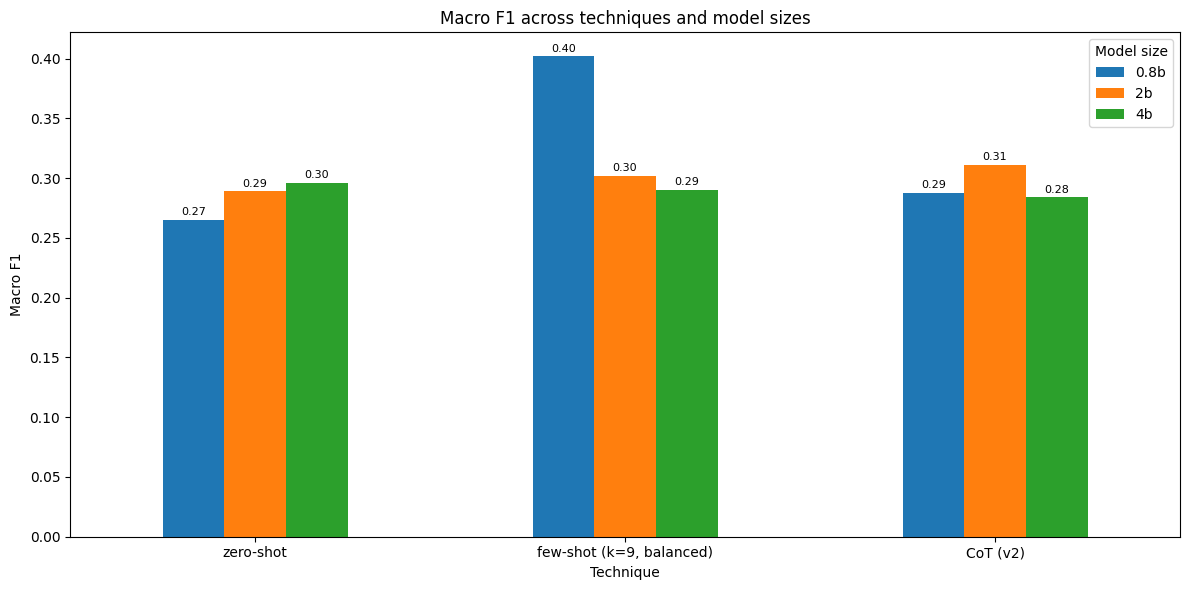

In [215]:
# Plot grouped bars
ax = pivot.plot(kind="bar", figsize=(12, 6))
ax.set_title("Macro F1 across techniques and model sizes")
ax.set_xlabel("Technique")
ax.set_ylabel("Macro F1")
ax.set_xticklabels(["zero-shot", "few-shot (k=9, balanced)", "CoT (v2)"], rotation=0)
plt.legend(title="Model size")

# Add value labels on top of each bar
for container in ax.containers:
  ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)

plt.tight_layout()
plt.savefig("cross-model-macro-f1-qwen3.5.png", dpi=150, bbox_inches="tight")
plt.show()

Macro F1 of all seven prompting techniques evaluated on Qwen3.5-0.8B, our most extensively tested model.

In [240]:
# Plot macro F1 on Qwen3.5-0.8B across all 7 techniques tried
TECHNIQUE_LABELS = {
  "zs": "zero-shot",
  "fs9": "few-shot (k=9, balanced)",
  "cot_v2": "CoT (v2)",
  "fscot": "few-shot CoT (k=3)",
  "genknow": "generate knowledge",
  "chain": "prompt chaining",
  "sc": "self-consistency*",
}

In [241]:
# Keep only 0.8b rows for the techniques we want to show
filtered_08 = []
for r in results:
  if r["model_size"] == "0.8b" and r["experiment"] in TECHNIQUE_LABELS:
    filtered_08.append(r)

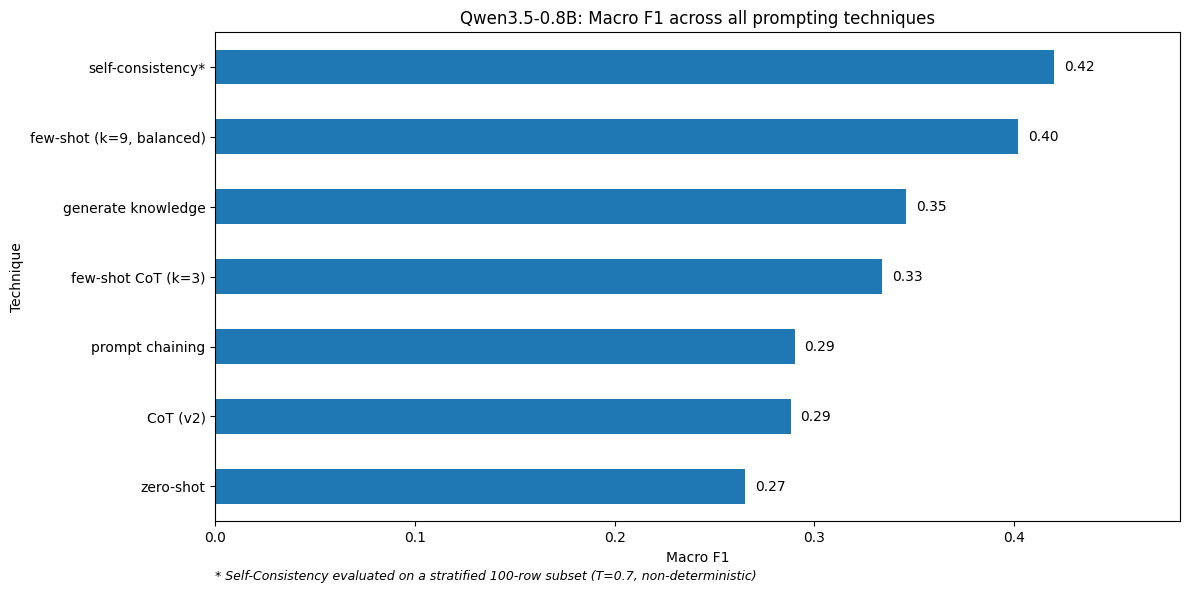

In [244]:
# Plot the bar chart
df_08 = pd.DataFrame(filtered_08).sort_values("macro_f1", ascending=True)
df_08["label"] = df_08["experiment"].map(TECHNIQUE_LABELS)

ax = df_08.plot(kind="barh", x="label", y="macro_f1", figsize=(12, 6), legend=False)
ax.set_title("Qwen3.5-0.8B: Macro F1 across all prompting techniques")
ax.set_xlabel("Macro F1")
ax.set_ylabel("Technique")
ax.set_xlim(0, df_08["macro_f1"].max() * 1.15)

# Value labels at end of each bar
for i, v in enumerate(df_08["macro_f1"]):
  ax.text(v + 0.005, i, f"{v:.2f}", va="center")

# SC caveat note
ax.text(0.0, -0.12, "* Self-Consistency evaluated on a stratified 100-row subset (T=0.7, non-deterministic)", transform=ax.transAxes, fontsize=9, style="italic")

plt.tight_layout()
plt.savefig("macro_f1_techniques_0.8b.png", dpi=150, bbox_inches="tight")
plt.show()

## Error Analysis

In [247]:
# Pick the winning model + technique for error analysis and the test set submission
# Selection: highest macro F1 on the full 509-row validation set with deterministic decoding (T=0)
# (Self-consistency reached 0.420 but on a 100-row subset with sampling at T=0.7, so not used here)
WINNING_MODEL_SIZE = "0.8b"
WINNING_TECHNIQUE = "fs9_balanced" # few-shot k=9, class-balanced demo sampling
WINNING_MAX_NEW_TOKENS = 50
WINNING_BATCH_SIZE = 8

print(f"Winner: Qwen3.5-{WINNING_MODEL_SIZE} with {WINNING_TECHNIQUE}, max_new_tokens = {WINNING_MAX_NEW_TOKENS}, temperature = {0}, batch_size = {WINNING_BATCH_SIZE}")

Winner: Qwen3.5-0.8b with fs9_balanced, max_new_tokens = 50, temperature = 0.0, batch_size = 8


In [248]:
# Build error_df: validation set with the winner's predictions attached
WINNER_COL = f"parsed_{WINNING_TECHNIQUE}_{WINNING_MODEL_SIZE}"

error_df = val_df.copy().reset_index(drop=True)
error_df["predicted"] = error_df[WINNER_COL]
error_df["true_label"] = error_df["clarity_label"]
error_df["correct"] = error_df["predicted"] == error_df["true_label"]

print(f"Prediction column: {WINNER_COL}")
print(f"Total validation samples: {len(error_df)}")
print(f"Correct: {error_df['correct'].sum()}")
print(f"Wrong: {(error_df['correct'] == False).sum()}")

Prediction column: parsed_fs9_balanced_0.8b
Total validation samples: 509
Correct: 243
Wrong: 266


In [250]:
# Classification report on the val set (winner predictions)
y_true = error_df["true_label"]
y_pred = error_df["predicted"].fillna("invalid") # invalid for parse fails (1 in total, conform it via confusion matrix below)

print(classification_report(y_true, y_pred, labels=VALID_LABELS))

                 precision    recall  f1-score   support

    Clear Reply       0.41      0.33      0.36       156
     Ambivalent       0.61      0.57      0.59       301
Clear Non-Reply       0.19      0.37      0.25        52

      micro avg       0.48      0.48      0.48       509
      macro avg       0.40      0.42      0.40       509
   weighted avg       0.50      0.48      0.49       509



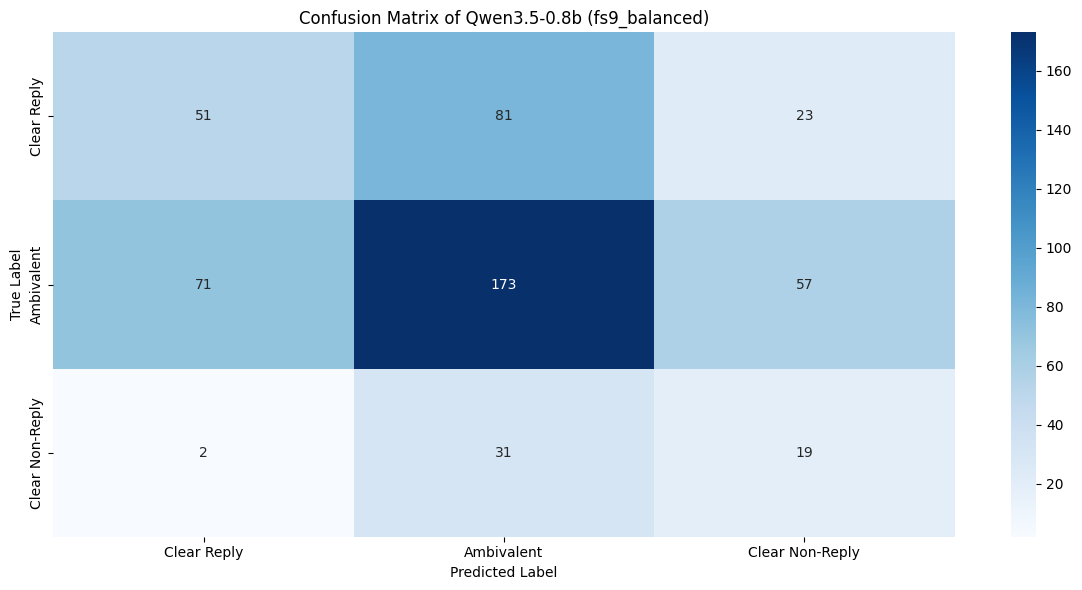

In [251]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=VALID_LABELS)
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=VALID_LABELS, yticklabels=VALID_LABELS)
plt.title(f"Confusion Matrix of Qwen3.5-{WINNING_MODEL_SIZE} ({WINNING_TECHNIQUE})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(f"confusion-matrix-qwen3.5-{WINNING_MODEL_SIZE}-{WINNING_TECHNIQUE}.png", dpi=150, bbox_inches="tight")
plt.show()

In [252]:
# Per-class accuracy: how well does the model do on each class?
print("Per-class accuracy:")
for label_name in VALID_LABELS:
  subset = error_df[error_df["true_label"] == label_name]
  acc = subset["correct"].mean()
  print(f"  {label_name}: {acc:.2f} ({subset['correct'].sum()}/{len(subset)})")

Per-class accuracy:
  Clear Reply: 0.33 (51/156)
  Ambivalent: 0.57 (173/301)
  Clear Non-Reply: 0.37 (19/52)


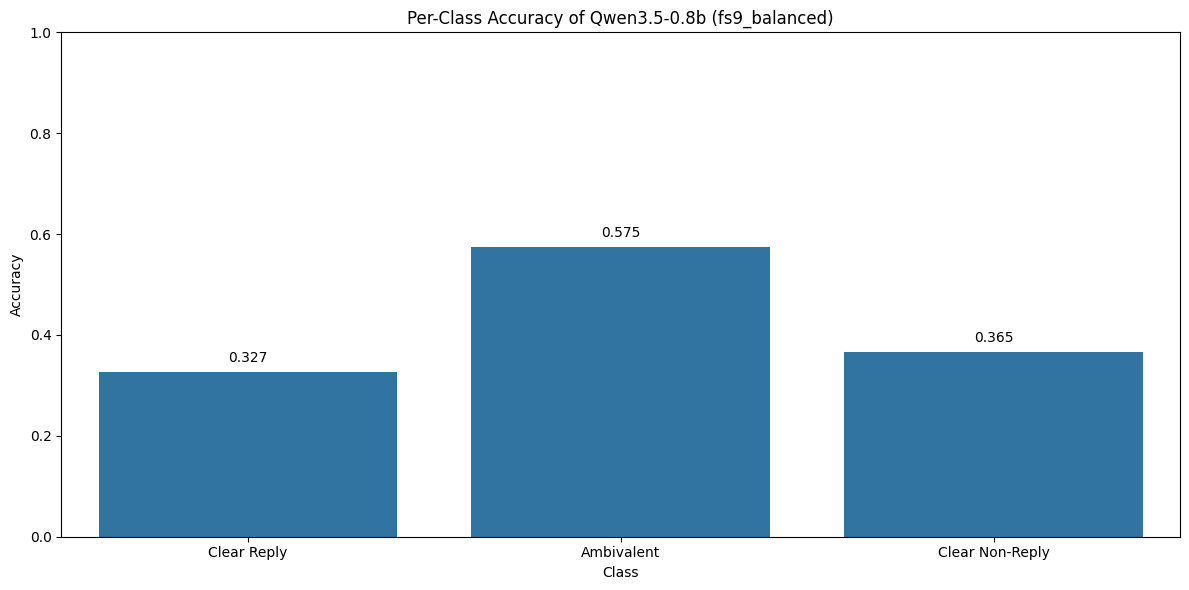

In [ ]:
# Bar chart
accuracies = [error_df[error_df["true_label"] == c]["correct"].mean() for c in VALID_LABELS]

plt.figure(figsize=(12, 6))
sns.barplot(x=VALID_LABELS, y=accuracies)
plt.title(f"Per-Class Accuracy of Qwen3.5-{WINNING_MODEL_SIZE} ({WINNING_TECHNIQUE})")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
  plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig(f"per-class-accuracy-qwen3.5-{WINNING_MODEL_SIZE}-{WINNING_TECHNIQUE}.png", dpi=150, bbox_inches="tight")
plt.show()

In [254]:
# Show some error examples per class
NUM_EXAMPLES = 3
RESPONSE_COL = f"response_{WINNING_TECHNIQUE}_{WINNING_MODEL_SIZE}"

for label_name in ["Clear Reply", "Ambivalent", "Clear Non-Reply"]:
  print(f"\n=== Errors for true label: {label_name} ===")
  errors = error_df[(error_df["true_label"] == label_name) & (error_df["correct"] == False)]
  for i, row in errors.head(NUM_EXAMPLES).iterrows():
    print(f"\nQuestion: {row['question']}")
    print(f"Answer: {row['interview_answer']}")
    print(f"True: {row['true_label']}  |  Predicted: {row['predicted']}")
    print(f"Model response: {row[RESPONSE_COL]}")
    print("-" * 80)


=== Errors for true label: Clear Reply ===

Question: Could the terror threats be the reason you have skipped Kenya in your visits to Africa?
Answer: Oh, no, no, no. [] The—well, first of all, with respect to journalists in the media, the last session that we had on good governance emphasized that good governance means everybody has a voice, that government is transparent and thereby accountable. And even though leaders don't always like it, the media plays a crucial role in assuring people that they have the proper information to evaluate the policies that their leaders are pursuing.And so we have been very consistent in pushing governments not just in Africa, but around the world, to respect the right of journalists to practice their trade as a critical part of civil society and a critical part of any democratic norm. The specific issue of the Al Jazeera journalists in Egypt, we've been clear both publicly and privately that they should be released. And we have been troubled by some

In [255]:
# Error rate by answer length: check if model accuracy depends on answer length
error_df["answer_len"] = error_df["interview_answer"].str.split().str.len()

# Divide answers into 4 length groups: Short (<50 words), Medium (50-150), Long (150-300), Very Long (>300)
error_df["answer_len_group"] = pd.cut(error_df["answer_len"], bins=[0, 50, 150, 300, 2300], labels=["Short", "Medium", "Long", "Very Long"])

# Calculate accuracy and errors per answer length group
summary = error_df.groupby("answer_len_group", observed=True).agg(
  total_samples=("correct", "count"),
  errors=("correct", lambda x: (x == False).sum()),
  accuracy=("correct", "mean"),
)
summary["error_rate"] = summary["errors"] / summary["total_samples"]
display(summary)

,total_samples,errors,accuracy,error_rate
answer_len_group,,,,
Short,104,58,0.442308,0.557692
Medium,98,54,0.448980,0.551020
Long,101,48,0.524752,0.475248
Very Long,206,106,0.485437,0.514563


In [256]:
# Error rate by question length: check if model accuracy depends on question length
error_df["question_len"] = error_df["question"].str.split().str.len()

# Divide questions into 4 length groups: Short (<10 words), Medium (10-20), Long (20-30), Very Long (>30)
error_df["question_len_group"] = pd.cut(error_df["question_len"], bins=[0, 10, 20, 30, 100], labels=["Short", "Medium", "Long", "Very Long"])

# Calculate accuracy and errors per question length group
summary_q = error_df.groupby("question_len_group", observed=True).agg(
  total_samples=("correct", "count"),
  errors=("correct", lambda x: (x == False).sum()),
  accuracy=("correct", "mean"),
)
summary_q["error_rate"] = summary_q["errors"] / summary_q["total_samples"]
display(summary_q)

,total_samples,errors,accuracy,error_rate
question_len_group,,,,
Short,183,98,0.464481,0.535519
Medium,221,109,0.506787,0.493213
Long,75,43,0.426667,0.573333
Very Long,30,16,0.466667,0.533333


In [257]:
# Error rate across politicians
summary_p = error_df.groupby("president", observed=True).agg(
  total_samples=("correct", "count"),
  errors=("correct", lambda x: (x == False).sum()),
  accuracy=("correct", "mean"),
)
summary_p["error_rate"] = summary_p["errors"] / summary_p["total_samples"]
display(summary_p.sort_values("accuracy"))

,total_samples,errors,accuracy,error_rate
president,,,,
Joseph R. Biden,55,33,0.400000,0.600000
Barack Obama,162,88,0.456790,0.543210
Donald J. Trump,183,97,0.469945,0.530055
George W. Bush,109,48,0.559633,0.440367


In [258]:
# Most common misclassification pairs
print("Most common misclassification pairs (true -> predicted):")
errors = error_df[error_df["correct"] == False]
misclassifications = errors.groupby(["true_label", "predicted"]).size().reset_index(name="count")
misclassifications = misclassifications.sort_values("count", ascending=False)
display(misclassifications)

Most common misclassification pairs (true -> predicted):


,true_label,predicted,count
4,Clear Reply,Ambivalent,81
1,Ambivalent,Clear Reply,71
0,Ambivalent,Clear Non-Reply,57
2,Clear Non-Reply,Ambivalent,31
5,Clear Reply,Clear Non-Reply,23
3,Clear Non-Reply,Clear Reply,2


In [264]:
# Cross-size failure comparison: WINNING_TECHNIQUE at each model size
rows = []
for size in MODEL_SIZES:
  col = f"parsed_{WINNING_TECHNIQUE}_{size}"
  pred = val_df[col].fillna("invalid")
  true = val_df["clarity_label"]
  correct = pred == true

  row = {"model_size": size}

  # Per-class accuracy
  for label in VALID_LABELS:
    mask = true == label
    row[f"acc_{label}"] = correct[mask].mean()

  # Top misclassification pair
  pair_counts = Counter()
  for t, p, c in zip(true, pred, correct):
    if not c:
      pair_counts[(t, p)] += 1
  top_pair, top_n = pair_counts.most_common(1)[0]
  row["top_misclass"] = f"{top_pair[0]} -> {top_pair[1]} ({top_n})"

  # Parse failure rate
  row["parse_fail_rate"] = (pred == "invalid").mean()
  rows.append(row)

cross_size = pd.DataFrame(rows)
display(cross_size.round(3))

,model_size,acc_Clear Reply,acc_Ambivalent,acc_Clear Non-Reply,top_misclass,parse_fail_rate
0,0.8b,0.327,0.575,0.365,Clear Reply -> Ambivalent (81),0.002
1,2b,0.859,0.007,0.712,Ambivalent -> Clear Reply (207),0.000
2,4b,0.833,0.007,0.712,Ambivalent -> Clear Reply (175),0.000


In [265]:
# Cross-technique failure comparison: each technique at 0.8B
SIZE = "0.8b"
TECHNIQUES = ["zs", "fs9_balanced", "cot_v2", "fscot_balanced", "genknow", "chain", "sc"]
TECHNIQUES = [t for t in TECHNIQUES if f"parsed_{t}_{SIZE}" in val_df.columns]
print(f"Techniques included: {TECHNIQUES}")

rows = []
for tech in TECHNIQUES:
  col = f"parsed_{tech}_{SIZE}"
  pred = val_df[col]
  true = val_df["clarity_label"]
  correct = pred == true

  row = {"technique": tech}

  for label in VALID_LABELS:
    mask = true == label
    row[f"acc_{label}"] = correct[mask].mean()

  pair_counts = Counter()
  for t, p, c in zip(true, pred, correct):
    if not c:
      pair_counts[(t, p)] += 1
  top_pair, top_n = pair_counts.most_common(1)[0]
  row["top_misclass"] = f"{top_pair[0]} -> {top_pair[1]} ({top_n})"

  row["parse_fail_rate"] = (pred.isna() | (pred == "invalid")).mean()
  rows.append(row)

cross_tech = pd.DataFrame(rows)
display(cross_tech.round(3))

Techniques included: ['zs', 'fs9_balanced', 'cot_v2', 'genknow', 'chain']


,technique,acc_Clear Reply,acc_Ambivalent,acc_Clear Non-Reply,top_misclass,parse_fail_rate
0,zs,0.179,0.365,0.308,Ambivalent -> Clear Non-Reply (147),0.004
1,fs9_balanced,0.327,0.575,0.365,Clear Reply -> Ambivalent (81),0.002
2,cot_v2,0.571,0.083,0.558,Ambivalent -> Clear Reply (129),0.118
3,genknow,0.429,0.472,0.154,Ambivalent -> Clear Reply (101),0.000
4,chain,0.551,0.060,0.904,Ambivalent -> Clear Non-Reply (166),0.000


In [267]:
# Parse-failure inspection: most common failed responses per technique
SIZE = "0.8b"
TOP_N = 5

TECHS_TO_INSPECT = TECHNIQUES + ["zs_no_labels", "zs_no_system", "zs_no_format"]

for tech in TECHS_TO_INSPECT:
  parsed_col = f"parsed_{tech}_{SIZE}"
  resp_col = f"response_{tech}_{SIZE}"
  if parsed_col not in val_df.columns or resp_col not in val_df.columns:
    continue

  failed_mask = val_df[parsed_col].isna() | (val_df[parsed_col] == "invalid")
  n_failed = failed_mask.sum()
  if n_failed < 5:
    continue

  print(f"\n{'=' * 70}")
  print(f"{tech}: {n_failed}/{len(val_df)} parse failures ({n_failed/len(val_df):.1%})")
  print('=' * 70)

  # Count the most common failed responses
  response_counts = Counter()
  for r in val_df.loc[failed_mask, resp_col]:
    if isinstance(r, str):
      response_counts[r.strip()[:200]] += 1

  print(f"\nTop {TOP_N} most common failed responses:")
  for i, (resp, count) in enumerate(response_counts.most_common(TOP_N), 1):
    print(f"\n  [{i}] count = {count}")
    print(f"      {resp}")


cot_v2: 60/509 parse failures (11.8%)

Top 5 most common failed responses:

  [1] count = 1
      Step 1: Analyze the question. The question asks if the party intends to support nuclear power, offshore drilling, and free trade as a single, unified package.

Step 2: Analyze the answer's structure. 

  [2] count = 1
      Step 1: Analyze the question. The question asks if the speaker is willing to change specific demands they previously gave to Congress in exchange for an amnesty. This implies a conditional relationshi

  [3] count = 1
      Step 1: Analyze the question. The question asks specifically about "concerns from the Americans" regarding the "Kaesong industrial complex."

Step 2: Scan the provided text for mentions of "Americans"

  [4] count = 1
      Step 1: Analyze the question. The question asks whether the "single coalition" mentioned by President Hollande is no longer existent.

Step 2: Analyze the answer text. The answer begins by discussing 

  [5] count = 1
      Step 

## Performance on Test Set

For the test set we use Qwen3.5-0.8B with few-shot (k=9, balanced). Self-Consistency on Qwen3.5-0.8B did reach a higher macro F1, but it was scored on a 100-row subset rather than the full validation set, so the comparison is not directly fair. We also keep the choice within the three basic techniques (zero-shot, few-shot, chain-of-thought), since those are the only ones we ran on every model size.

In [275]:
# Free GPU memory and delete the previous model
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

[before cleanup] allocated: 8.42 GB | reserved: 19.32 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


### Evaluate on Test Set

In [276]:
# Reload best perfoming model
model_path = "Qwen/Qwen3.5-0.8B"
tokenizer = AutoTokenizer.from_pretrained(model_path, padding_side="left")
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_path, torch_dtype=torch.bfloat16, device_map="auto")
print(model.config._name_or_path)

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Qwen/Qwen3.5-0.8B


In [277]:
# Run winner config (fs9_balanced, k=9) on the test set (bypass run_one_fs_experiment which is hardcoded to val_df and call run_few_shot_inference directly)

# Sample the SAME balanced demos used in the fs9 validation experiment and because SEED is fixed, sample_balanced_demos returns the same demos as in the val run
fs_demos = sample_balanced_demos(pool_df, k=9)

# Inference on test_df
start = time.time()
test_df["response"] = run_few_shot_inference(test_df, fs_demos, batch_size=WINNING_BATCH_SIZE, max_new_tokens=WINNING_MAX_NEW_TOKENS)
elapsed = time.time() - start

# Parse labels
test_df["parsed"] = test_df["response"].apply(parse_response)

print(f"Inference completed in {elapsed:.2f}s on {len(test_df)} test examples")
print(f"Parse failures: {(test_df['parsed'].isna() | (test_df['parsed'] == 'invalid')).sum()}")

Inference completed in 49.01s on 308 test examples
Parse failures: 0


In [278]:
# Visual sanity check: peek at a few test predictions
sample = test_df.sample(3, random_state=SEED)
for _, row in sample.iterrows():
  print(f"Question: {row['question']}")
  print(f"Gold: {row['clarity_label']}")
  print(f"Parsed: {row['parsed']}\n")
  print(f"Raw response: {row['response']}\n")

Question: What does President Kikwete think it says about America, that the country might elect a black President with African roots?
Gold: Clear Non-Reply
Parsed: Ambivalent

Raw response: Ambivalent


Question: Isn't Tehran's influence in the region growing despite your efforts to curb it?
Gold: Ambivalent
Parsed: Ambivalent

Raw response: Ambivalent


Question: Administration's contingency plans for his death
Gold: Ambivalent
Parsed: Ambivalent

Raw response: Ambivalent




In [279]:
# Classification report on test set
y_true = test_df["clarity_label"]
y_pred = test_df["parsed"].fillna("invalid") # parse failures become "invalid" so sklearn doesn't fail on NaN

print(classification_report(y_true, y_pred, labels=VALID_LABELS))

                 precision    recall  f1-score   support

    Clear Reply       0.38      0.35      0.37        79
     Ambivalent       0.74      0.69      0.71       206
Clear Non-Reply       0.26      0.48      0.34        23

       accuracy                           0.59       308
      macro avg       0.46      0.51      0.47       308
   weighted avg       0.61      0.59      0.60       308



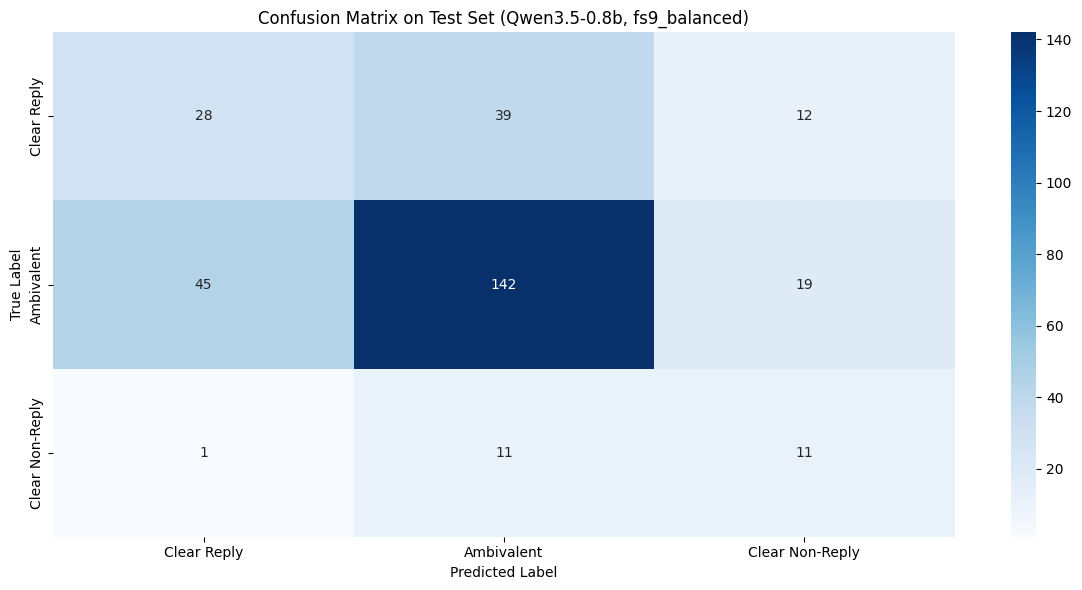

In [280]:
# Confusion matrix on the test set
cm = confusion_matrix(y_true, y_pred, labels=VALID_LABELS)

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=VALID_LABELS, yticklabels=VALID_LABELS)
plt.title(f"Confusion Matrix on Test Set (Qwen3.5-{WINNING_MODEL_SIZE}, {WINNING_TECHNIQUE})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(f"confusion-matrix-test-set-qwen3.5-{WINNING_MODEL_SIZE}-{WINNING_TECHNIQUE}.png", dpi=150, bbox_inches="tight")
plt.show()

### Generate submission.csv

In [355]:
# Build the submission DataFrame for Kaggle
submission = pd.DataFrame({
    "Id": test_df.index,
    "Predicted": test_df["parsed"].fillna("Ambivalent"), # Fall back to "Ambivalent" (majority class) on parse failure: Kaggle only accepts the 3 valid labels, so "invalid" would be scored wrong

})

submission.to_csv("submission.csv", index=False)
print(f"Saved submission.csv with {len(submission)} rows")

Saved submission.csv with 308 rows


In [356]:
# Display first 3 rows of submission file to verify format
display(submission.head(3))

,Id,Predicted
0,0,Clear Reply
1,1,Clear Non-Reply
2,2,Ambivalent


## Appendix

In this appendix we test three other model families (Llama-3.2, Gemma-3, Phi-4-mini) using the setup that worked best on Qwen3.5-0.8B: zero-shot, few-shot (k=9, balanced), and CoT v2. A fully fair comparison would tune each model separately, but compute limits keep us to one shared configuration.

### Gemma-3-1B-it

**Load Model**

In [286]:
# Free GPU memory and delete the previous model
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

# Load 1B Gemma-3
MODEL_NAME = "google/gemma-3-1b-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

# Inspect
n_params = sum(p.numel() for p in model.parameters())
print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")
print(f"Dtype: {model.dtype}")
print(f"Vocab size: {model.config.vocab_size:,}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")

# Tokenizer setup for batched generation
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
print(f"pad_token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Model name: google/gemma-3-1b-it
Total parameters: 999,885,952 (1.00B)
Context length: 32,768 tokens
Dtype: torch.bfloat16
Vocab size: 262,144
Hidden size: 1152
Num layers: 26
Num attention heads: 4
pad_token: <pad> (id=0)


**Experiments**

In [287]:
# All 3 basic experiments on Gemma-3-1B
BATCH_SIZE = 8

# Cross-family results table
appendix_results = []

# appendix_results.append(run_one_zs_experiment(model_name="Gemma-3", model_size="1b"))
# appendix_results.append(run_one_fs_experiment(k=9, strategy="balanced", model_name="Gemma-3", model_size="1b"))
# appendix_results.append(run_one_cot_experiment(prompt_variant="v2", system_prompt_arg=system_cot_prompt2, model_name="Gemma-3", model_size="1b"))


Trying zs on Gemma-3-1b...
Inference completed in 29.67s on 509 val examples
Archived responses to val_df['response_zs_1b'] and predictions to val_df['parsed_zs_1b']

Trying few-shot on Gemma-3-1b with 9 balanced examples...
Inference completed in 45.72s on 509 val examples
Archived responses to val_df['response_fs9_balanced_1b'] and predictions to val_df['parsed_fs9_balanced_1b']

Trying CoT on Gemma-3-1b with prompt v2...
Inference completed in 630.79s on 509 val examples
Archived responses to val_df['response_cot_v2_1b'] and predictions to val_df['parsed_cot_v2_1b']


In [289]:
# Hardcoded results from the actual run
gemma1b_results = [
  # zs
  {"model": "Gemma-3", "model_size": "1b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 8, "inference_time": 29.669, "accuracy": 0.310, "macro_f1": 0.276, "weighted_f1": 0.217, "parse_failure_rate": 0.041},
  # fs9 balanced
  {"model": "Gemma-3", "model_size": "1b", "experiment": "fs9", "few_shot_k": 9, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 8, "inference_time": 45.722, "accuracy": 0.324, "macro_f1": 0.255, "weighted_f1": 0.360, "parse_failure_rate": 0.016},
  # cot_v2
  {"model": "Gemma-3", "model_size": "1b", "experiment": "cot_v2", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300,
   "batch_size": 8, "inference_time": 630.792, "accuracy": 0.352, "macro_f1": 0.305, "weighted_f1": 0.320, "parse_failure_rate": 0.004},
]

### Gemma-3-4B-it

**Load Model**

In [291]:
# Free GPU memory and delete the previous model
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

# Load 4B Gemma-3
MODEL_NAME = "google/gemma-3-4b-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

# Inspect
n_params = sum(p.numel() for p in model.parameters())
cfg = model.config
text_cfg = getattr(cfg, "text_config", cfg)  # Gemma-3 nests text params

print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {text_cfg.max_position_embeddings:,} tokens")
print(f"Dtype: {model.dtype}")
print(f"Vocab size: {text_cfg.vocab_size:,}")
print(f"Hidden size: {text_cfg.hidden_size}")
print(f"Num layers: {text_cfg.num_hidden_layers}")
print(f"Num attention heads: {text_cfg.num_attention_heads}")

# Tokenizer setup for batched generation
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
print(f"pad_token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")

[before cleanup] allocated: 8.61 GB | reserved: 8.76 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Model name: google/gemma-3-4b-it
Total parameters: 4,300,079,472 (4.30B)
Context length: 131,072 tokens
Dtype: torch.bfloat16
Vocab size: 262,208
Hidden size: 2560
Num layers: 34
Num attention heads: 8
pad_token: <pad> (id=0)


**Experiments**

In [292]:
# All 3 basic experiments on Gemma-3-4B
BATCH_SIZE = 4

# appendix_results.append(run_one_zs_experiment(model_name="Gemma-3", model_size="4b"))
# appendix_results.append(run_one_fs_experiment(k=9, strategy="balanced", model_name="Gemma-3", model_size="4b"))
# appendix_results.append(run_one_cot_experiment(prompt_variant="v2", system_prompt_arg=system_cot_prompt2, model_name="Gemma-3", model_size="4b"))


Trying zs on Gemma-3-4b...
Inference completed in 51.77s on 509 val examples
Archived responses to val_df['response_zs_4b'] and predictions to val_df['parsed_zs_4b']

Trying few-shot on Gemma-3-4b with 9 balanced examples...
Inference completed in 116.18s on 509 val examples
Archived responses to val_df['response_fs9_balanced_4b'] and predictions to val_df['parsed_fs9_balanced_4b']

Trying CoT on Gemma-3-4b with prompt v2...
Inference completed in 2705.62s on 509 val examples
Archived responses to val_df['response_cot_v2_4b'] and predictions to val_df['parsed_cot_v2_4b']


In [294]:
# Hardcoded results from the actual run
gemma4b_results = [
  # zs
  {"model": "Gemma-3", "model_size": "4b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 51.773, "accuracy": 0.507, "macro_f1": 0.440, "weighted_f1": 0.512, "parse_failure_rate": 0.010},
  # fs9 balanced
  {"model": "Gemma-3", "model_size": "4b", "experiment": "fs9", "few_shot_k": 9, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 116.175, "accuracy": 0.348, "macro_f1": 0.312, "weighted_f1": 0.266, "parse_failure_rate": 0.000},
  # cot_v2
  {"model": "Gemma-3", "model_size": "4b", "experiment": "cot_v2", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300,
   "batch_size": 4, "inference_time": 2705.622, "accuracy": 0.273, "macro_f1": 0.312, "weighted_f1": 0.339, "parse_failure_rate": 0.334},
]

### Llama-3.2-1B-Instruct

**Load Model**

In [295]:
# Free GPU memory and delete the previous model
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

# Load Llama-3.2-1B
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

# Inspect
n_params = sum(p.numel() for p in model.parameters())
print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")
print(f"Dtype: {model.dtype}")
print(f"Vocab size: {model.config.vocab_size:,}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")

# Tokenizer setup for batched generation
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
print(f"pad_token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")

[before cleanup] allocated: 8.61 GB | reserved: 16.01 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model name: meta-llama/Llama-3.2-1B-Instruct
Total parameters: 1,235,814,400 (1.24B)
Context length: 131,072 tokens
Dtype: torch.bfloat16
Vocab size: 128,256
Hidden size: 2048
Num layers: 16
Num attention heads: 32
pad_token: <|eot_id|> (id=128009)


**Experiments**

In [296]:
# All 3 basic experiments on Llama-3.2-1B
BATCH_SIZE = 8

# appendix_results.append(run_one_zs_experiment(model_name="Llama-3.2", model_size="1b"))
# appendix_results.append(run_one_fs_experiment(k=9, strategy="balanced", model_name="Llama-3.2", model_size="1b"))
# appendix_results.append(run_one_cot_experiment(prompt_variant="v2", system_prompt_arg=system_cot_prompt2, model_name="Llama-3.2", model_size="1b"))


Trying zs on Llama-3.2-1b...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Inference completed in 20.71s on 509 val examples
Archived responses to val_df['response_zs_1b'] and predictions to val_df['parsed_zs_1b']

Trying few-shot on Llama-3.2-1b with 9 balanced examples...
Inference completed in 33.55s on 509 val examples
Archived responses to val_df['response_fs9_balanced_1b'] and predictions to val_df['parsed_fs9_balanced_1b']

Trying CoT on Llama-3.2-1b with prompt v2...
Inference completed in 437.28s on 509 val examples
Archived responses to val_df['response_cot_v2_1b'] and predictions to val_df['parsed_cot_v2_1b']


In [298]:
# Hardcoded results from the actual run
llama1b_results = [
  # zs
  {"model": "Llama-3.2", "model_size": "1b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 8, "inference_time": 20.708, "accuracy": 0.167, "macro_f1": 0.131, "weighted_f1": 0.121, "parse_failure_rate": 0.460},
  # fs9 balanced
  {"model": "Llama-3.2", "model_size": "1b", "experiment": "fs9", "few_shot_k": 9, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 8, "inference_time": 33.547, "accuracy": 0.306, "macro_f1": 0.156, "weighted_f1": 0.144, "parse_failure_rate": 0.000},
  # cot_v2
  {"model": "Llama-3.2", "model_size": "1b", "experiment": "cot_v2", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300,
   "batch_size": 8, "inference_time": 437.279, "accuracy": 0.360, "macro_f1": 0.309, "weighted_f1": 0.357, "parse_failure_rate": 0.004},
]

### Llama-3.2-3B-Instruct

**Load Model**

In [299]:
# Free GPU memory and delete the previous model
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

# Load 3B Llama-3.2
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

# Inspect
n_params = sum(p.numel() for p in model.parameters())
print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")
print(f"Dtype: {model.dtype}")
print(f"Vocab size: {model.config.vocab_size:,}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")

# Tokenizer setup for batched generation
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
print(f"pad_token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")

[before cleanup] allocated: 2.48 GB | reserved: 12.94 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model name: meta-llama/Llama-3.2-3B-Instruct
Total parameters: 3,212,749,824 (3.21B)
Context length: 131,072 tokens
Dtype: torch.bfloat16
Vocab size: 128,256
Hidden size: 3072
Num layers: 28
Num attention heads: 24
pad_token: <|eot_id|> (id=128009)


**Experiments**

In [300]:
# All 3 basic experiments on Llama-3.2-3B
BATCH_SIZE = 4

# appendix_results.append(run_one_zs_experiment(model_name="Llama-3.2", model_size="3b"))
# appendix_results.append(run_one_fs_experiment(k=9, strategy="balanced", model_name="Llama-3.2", model_size="3b"))
# appendix_results.append(run_one_cot_experiment(prompt_variant="v2", system_prompt_arg=system_cot_prompt2, model_name="Llama-3.2", model_size="3b"))


Trying zs on Llama-3.2-3b...
Inference completed in 32.92s on 509 val examples
Archived responses to val_df['response_zs_3b'] and predictions to val_df['parsed_zs_3b']

Trying few-shot on Llama-3.2-3b with 9 balanced examples...
Inference completed in 82.82s on 509 val examples
Archived responses to val_df['response_fs9_balanced_3b'] and predictions to val_df['parsed_fs9_balanced_3b']

Trying CoT on Llama-3.2-3b with prompt v2...
Inference completed in 1331.83s on 509 val examples
Archived responses to val_df['response_cot_v2_3b'] and predictions to val_df['parsed_cot_v2_3b']


In [302]:
# Hardcoded results from the actual run
llama3b_results = [
  # zs
  {"model": "Llama-3.2", "model_size": "3b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 32.924, "accuracy": 0.407, "macro_f1": 0.389, "weighted_f1": 0.368, "parse_failure_rate": 0.000},
  # fs9 balanced
  {"model": "Llama-3.2", "model_size": "3b", "experiment": "fs9", "few_shot_k": 9, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 82.824, "accuracy": 0.320, "macro_f1": 0.282, "weighted_f1": 0.190, "parse_failure_rate": 0.000},
  # cot_v2
  {"model": "Llama-3.2", "model_size": "3b", "experiment": "cot_v2", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300,
   "batch_size": 4, "inference_time": 1331.827, "accuracy": 0.356, "macro_f1": 0.361, "weighted_f1": 0.349, "parse_failure_rate": 0.037},
]

### Phi-4-mini-instruct

**Load Model**

In [303]:
# Free GPU memory and delete the previous model
show_gpu_mem("before cleanup")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
show_gpu_mem("after cleanup")

# Load Phi-4-mini
MODEL_NAME = "microsoft/Phi-4-mini-instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto")

# Inspect
n_params = sum(p.numel() for p in model.parameters())
print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")
print(f"Dtype: {model.dtype}")
print(f"Vocab size: {model.config.vocab_size:,}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")

# Tokenizer setup for batched generation
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
print(f"pad_token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")

[before cleanup] allocated: 6.43 GB | reserved: 12.51 GB
[after cleanup] allocated: 0.01 GB | reserved: 1.51 GB


config.json: 0.00B [00:00, ?B/s]

[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Model name: microsoft/Phi-4-mini-instruct
Total parameters: 3,836,021,760 (3.84B)
Context length: 131,072 tokens
Dtype: torch.bfloat16
Vocab size: 200,064
Hidden size: 3072
Num layers: 32
Num attention heads: 24
pad_token: <|endoftext|> (id=199999)


**Experiments**

In [304]:
# All 3 basic experiments on Phi-4-mini
BATCH_SIZE = 4

# appendix_results.append(run_one_zs_experiment(model_name="Phi-4-mini", model_size="3.8b"))
# appendix_results.append(run_one_fs_experiment(k=9, strategy="balanced", model_name="Phi-4-mini", model_size="3.8b"))
# appendix_results.append(run_one_cot_experiment(prompt_variant="v2", system_prompt_arg=system_cot_prompt2, model_name="Phi-4-mini", model_size="3.8b"))


Trying zs on Phi-4-mini-3.8b...
Inference completed in 35.45s on 509 val examples
Archived responses to val_df['response_zs_3.8b'] and predictions to val_df['parsed_zs_3.8b']

Trying few-shot on Phi-4-mini-3.8b with 9 balanced examples...
Inference completed in 83.85s on 509 val examples
Archived responses to val_df['response_fs9_balanced_3.8b'] and predictions to val_df['parsed_fs9_balanced_3.8b']

Trying CoT on Phi-4-mini-3.8b with prompt v2...
Inference completed in 1001.06s on 509 val examples
Archived responses to val_df['response_cot_v2_3.8b'] and predictions to val_df['parsed_cot_v2_3.8b']


In [306]:
# Hardcoded results from the actual run
phi4_results = [
  # zs
  {"model": "Phi-4-mini", "model_size": "3.8b", "experiment": "zs", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 35.454, "accuracy": 0.580, "macro_f1": 0.382, "weighted_f1": 0.535, "parse_failure_rate": 0.000},
  # fs9 balanced
  {"model": "Phi-4-mini", "model_size": "3.8b", "experiment": "fs9", "few_shot_k": 9, "strategy": "balanced", "temperature": 0.0, "max_new_tokens": 50,
   "batch_size": 4, "inference_time": 83.852, "accuracy": 0.546, "macro_f1": 0.394, "weighted_f1": 0.526, "parse_failure_rate": 0.000},
  # cot_v2
  {"model": "Phi-4-mini", "model_size": "3.8b", "experiment": "cot_v2", "few_shot_k": 0, "strategy": "", "temperature": 0.0, "max_new_tokens": 300,
   "batch_size": 4, "inference_time": 1001.058, "accuracy": 0.503, "macro_f1": 0.419, "weighted_f1": 0.513, "parse_failure_rate": 0.000},
]

### Cross-Family Summary

In [307]:
# Combine all hardcoded per-model appendix tables
appendix_results_hc = gemma1b_results + gemma4b_results + llama1b_results + llama3b_results + phi4_results

In [310]:
# Display appendix results
appendix_df = pd.DataFrame(appendix_results_hc)
display(appendix_df.round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Gemma-3,1b,zs,0,,0.0,50,8,29.669,0.310,0.276,0.217,0.041
1,Gemma-3,1b,fs9,9,balanced,0.0,50,8,45.722,0.324,0.255,0.360,0.016
2,Gemma-3,1b,cot_v2,0,,0.0,300,8,630.792,0.352,0.305,0.320,0.004
3,Gemma-3,4b,zs,0,,0.0,50,4,51.773,0.507,0.440,0.512,0.010
4,Gemma-3,4b,fs9,9,balanced,0.0,50,4,116.175,0.348,0.312,0.266,0.000
5,Gemma-3,4b,cot_v2,0,,0.0,300,4,2705.622,0.273,0.312,0.339,0.334
6,Llama-3.2,1b,zs,0,,0.0,50,8,20.708,0.167,0.131,0.121,0.460
7,Llama-3.2,1b,fs9,9,balanced,0.0,50,8,33.547,0.306,0.156,0.144,0.000
8,Llama-3.2,1b,cot_v2,0,,0.0,300,8,437.279,0.360,0.309,0.357,0.004
9,Llama-3.2,3b,zs,0,,0.0,50,4,32.924,0.407,0.389,0.368,0.000


In [311]:
# Combine main-study Qwen rows (basic techniques only) with all appendix rows
qwen_basic = [r for r in results if r["experiment"] in ("zs", "fs9", "cot_v2")]
cross_family_results = qwen_basic + appendix_results_hc

cross_family_df = pd.DataFrame(cross_family_results)
cross_family_df = cross_family_df.sort_values(by=["model", "model_size", "experiment"]).reset_index(drop=True)
display(cross_family_df.round(3))

,model,model_size,experiment,few_shot_k,strategy,temperature,max_new_tokens,batch_size,inference_time,accuracy,macro_f1,weighted_f1,parse_failure_rate
0,Gemma-3,1b,cot_v2,0,,0.0,300,8,630.792,0.352,0.305,0.320,0.004
1,Gemma-3,1b,fs9,9,balanced,0.0,50,8,45.722,0.324,0.255,0.360,0.016
2,Gemma-3,1b,zs,0,,0.0,50,8,29.669,0.310,0.276,0.217,0.041
3,Gemma-3,4b,cot_v2,0,,0.0,300,4,2705.622,0.273,0.312,0.339,0.334
4,Gemma-3,4b,fs9,9,balanced,0.0,50,4,116.175,0.348,0.312,0.266,0.000
5,Gemma-3,4b,zs,0,,0.0,50,4,51.773,0.507,0.440,0.512,0.010
6,Llama-3.2,1b,cot_v2,0,,0.0,300,8,437.279,0.360,0.309,0.357,0.004
7,Llama-3.2,1b,fs9,9,balanced,0.0,50,8,33.547,0.306,0.156,0.144,0.000
8,Llama-3.2,1b,zs,0,,0.0,50,8,20.708,0.167,0.131,0.121,0.460
9,Llama-3.2,3b,cot_v2,0,,0.0,300,4,1331.827,0.356,0.361,0.349,0.037


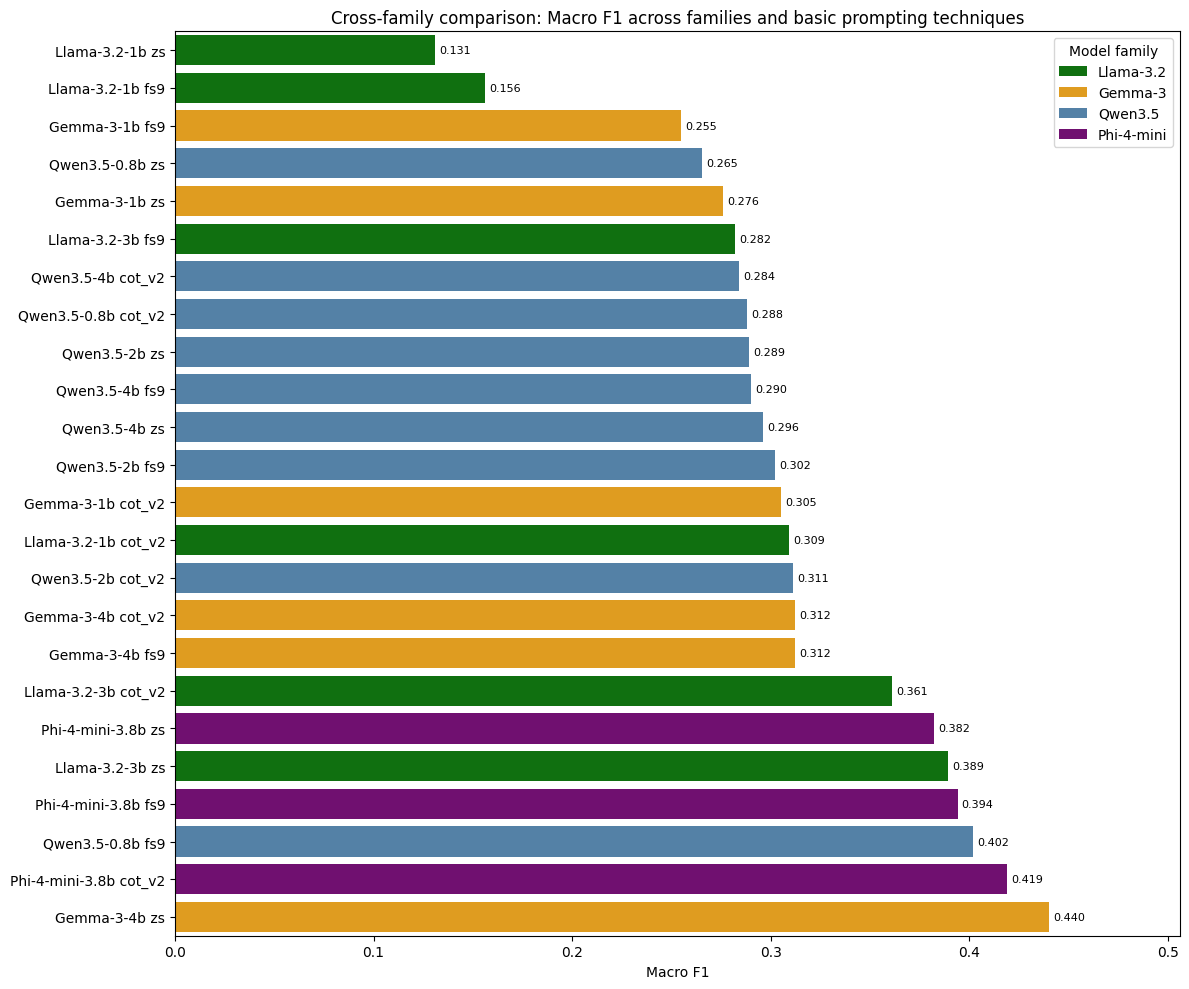

In [318]:
# Sort and label
plot_df = cross_family_df.copy()
plot_df["label"] = plot_df["model"] + "-" + plot_df["model_size"] + " " + plot_df["experiment"]
plot_df = plot_df.sort_values("macro_f1", ascending=True).reset_index(drop=True)

# Simple family colors
family_colors = {
  "Qwen3.5": "steelblue",
  "Gemma-3": "orange",
  "Llama-3.2": "green",
  "Phi-4-mini": "purple",
}

fig, ax = plt.subplots(figsize=(12, 10))
sns.barplot(data=plot_df, x="macro_f1", y="label", hue="model", palette=family_colors, dodge=False, ax=ax)

# Value labels at the end of each bar (same pattern you used in the cross-model Qwen chart)
for container in ax.containers:
  ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

ax.set_xlabel("Macro F1")
ax.set_ylabel("")
ax.set_title("Cross-family comparison: Macro F1 across families and basic prompting techniques")
ax.set_xlim(0, plot_df["macro_f1"].max() * 1.15)
ax.legend(title="Model family", loc="upper right")

plt.tight_layout()
plt.savefig("cross-family-macro-f1.png", dpi=150, bbox_inches="tight")
plt.show()

In [319]:
# Combined model+size label
df = cross_family_df.copy()
df["model_label"] = df["model"] + "-" + df["model_size"]

# Pivot: rows = technique, columns = model+size, values = macro_f1
pivot = df.pivot(index="experiment", columns="model_label", values="macro_f1")

BASIC_EXPERIMENTS = ["zs", "fs9", "cot_v2"]
COLUMN_ORDER = ["Qwen3.5-0.8b", "Qwen3.5-2b", "Qwen3.5-4b", "Gemma-3-1b", "Gemma-3-4b", "Llama-3.2-1b", "Llama-3.2-3b", "Phi-4-mini-3.8b"]
pivot = pivot.reindex(BASIC_EXPERIMENTS)[COLUMN_ORDER]
# print(pivot)

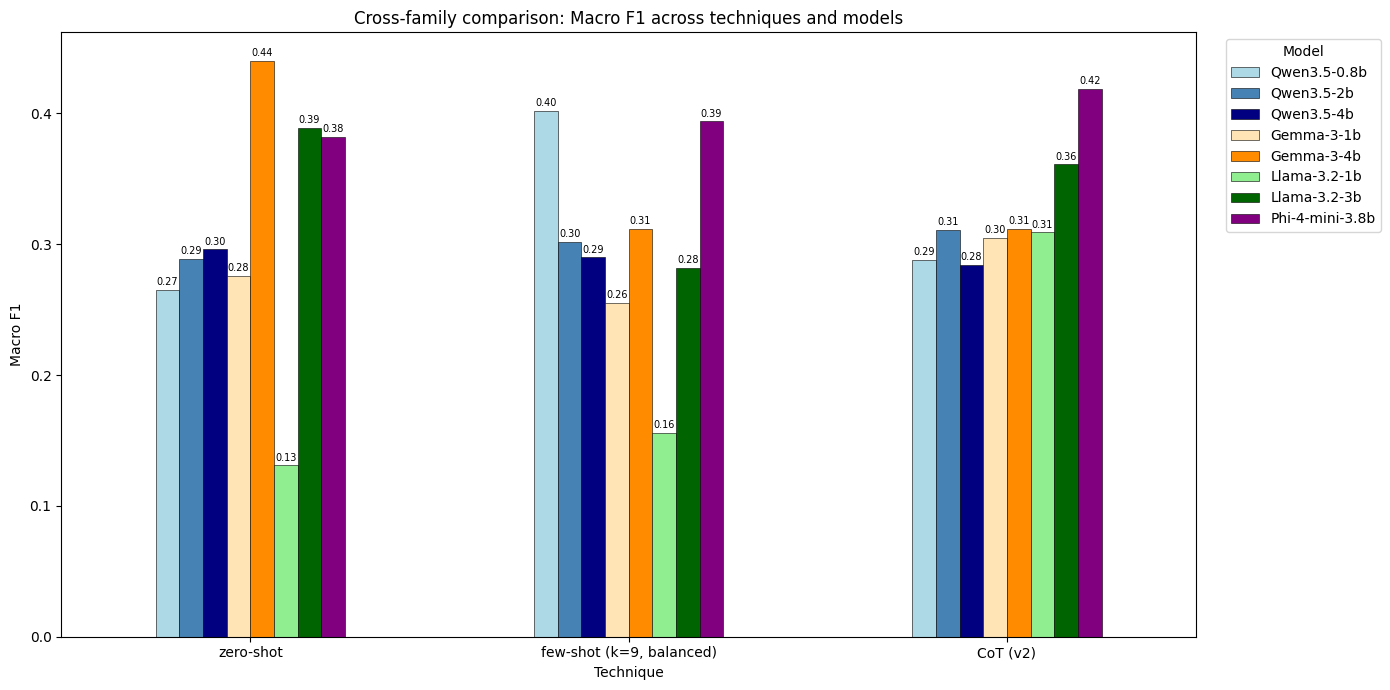

In [320]:
# Shaded named colors: each family has its own hue, sizes within family go light → dark
column_colors = [
  "lightblue", "steelblue", "navy", # Qwen3.5 sizes
  "moccasin", "darkorange", # Gemma-3 sizes
  "lightgreen", "darkgreen", # Llama-3.2 sizes
  "purple", # Phi-4-mini
]

ax = pivot.plot(kind="bar", figsize=(14, 7), color=column_colors, edgecolor="black", linewidth=0.4)
ax.set_title("Cross-family comparison: Macro F1 across techniques and models")
ax.set_xlabel("Technique")
ax.set_ylabel("Macro F1")
ax.set_xticklabels(["zero-shot", "few-shot (k=9, balanced)", "CoT (v2)"], rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

# Value labels on each bar
for container in ax.containers:
  ax.bar_label(container, fmt="%.2f", padding=2, fontsize=7)

plt.tight_layout()
plt.savefig("cross-family-macro-f1_2.png", dpi=150, bbox_inches="tight")
plt.show()

### Download all Results & Figures

In [321]:
# Zip all generated .png figures
# import zipfile
# import os

# with zipfile.ZipFile("figures.zip", "w") as zipf:
#   for f in os.listdir("."):
#     if f.endswith(".png"):
#       zipf.write(f)

In [322]:
# Zip all results tables as CSV
# pd.DataFrame(results).to_csv("results_main.csv", index=False)
# pd.DataFrame(ablation_results).to_csv("results_ablation.csv", index=False)
# pd.DataFrame(appendix_results_hc).to_csv("results_appendix.csv", index=False)
# cross_family_df.to_csv("results_cross_family.csv", index=False)

# with zipfile.ZipFile("results.zip", "w") as zipf:
#   for f in os.listdir("."):
#     if f.endswith(".csv") and f.startswith("results_"):
#       zipf.write(f)

In [323]:
# Download all generated zip files
# from google.colab import files
# files.download("figures.zip")
# files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## References


*   [Dataset](https://huggingface.co/datasets/ailsntua/QEvasion)
*   [Hugging Face, Chat Templates](https://huggingface.co/docs/transformers/main/en/chat_templating)
*   [Hugging Face, Text Generation](https://huggingface.co/docs/transformers/main/en/llm_tutorial)
*   [Hugging Face, Generation Strategies](https://huggingface.co/docs/transformers/en/generation_strategies)
*   [Hugging Face, Model Hub](https://huggingface.co/models)
*   [Prompting Techniques Guide, Prompting Techniques](https://www.promptingguide.ai/techniques)
*   [Sciki-Learn, Classification Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)